# Transformación y EDA — Base de Datos de Créditos
**Objetivo:** preparar y explorar la base de datos de créditos (`BD_creditos.csv`) para entender la calidad de los datos, sus tipos, distribuciones y relaciones con la variable objetivo `Pago_atiempo` (1 = pagó a tiempo, 0 = cayó en mora), como insumo para un futuro modelo de riesgo crediticio.

**Contenido**
1. Carga de datos
2. Exploración inicial de datos
3. Exploración de datos y descripción (EDA)


## 1. Carga de datos

In [1]:
# Importaciones necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configruación del display del dataframe
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_theme(style='whitegrid')

# Configuración de la ruta
RUTA = 'BD_creditos.csv'

In [2]:
# Leer el dataframe, el csv usa ';' como separador
df = pd.read_csv(RUTA, sep=';', decimal=',', encoding='utf-8-sig')
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones: 10763 filas x 23 columnas


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,4,7/01/2025 14:40,1852560,12,32,Empleado,3500000,1000000,128650,95.227787,795.0,0,2,0.0,0.0,NaN,NaN,0,0,0,916148.0,Creciente,1
1,4,9/01/2025 11:18,3181080,6,34,Empleado,5000000,2000000,441817,95.227787,796.0,0,7,0.0,0.0,NaN,NaN,0,0,0,4473774.0,Creciente,1
2,9,26/12/2024 18:52,670200,5,34,Independiente,5000000,2000000,108632,95.227787,727,5,0,0,274561,274561,NaN,2,0,1,NaN,NaN,1
3,9,4/12/2024 14:20,506807,2,25,Independiente,3000000,900000,199684,95.227787,864,8,1,0,27564,27564,NaN,1,0,6,NaN,NaN,1
4,4,30/04/2025 18:41,999780,10,26,Empleado,2000000,600000,92509,95.227787,771.0,0,3,0.0,0.0,NaN,NaN,0,0,0,61000.0,Creciente,1


El dataset tiene 10.763 datos y 23 variables

## 2. Exploración inicial de datos

### 2.1 Descripción general de los datos
Caracterización de cada variable según su naturaleza estadística:

| Variable | Tipo | Naturaleza |
|---|---|---|
| tipo_credito | Categórica | Nominal (codificada como número, pero es un código de categoría) |
| fecha_prestamo | Fecha | — |
| capital_prestado | Numérica | Continua |
| plazo_meses | Numérica | Discreta / puede tratarse como ordinal, según necesidad |
| edad_cliente | Numérica | Discreta |
| tipo_laboral | Categórica | Nominal |
| salario_cliente | Numérica | Continua |
| total_otros_prestamos | Numérica | Continua |
| cuota_pactada | Numérica | Continua |
| puntaje | Numérica | Continua |
| puntaje_datacredito | Numérica | Continua |
| cant_creditosvigentes | Numérica | Discreta |
| huella_consulta | Numérica | Discreta |
| saldo_mora | Numérica | Continua |
| saldo_total | Numérica | Continua |
| saldo_principal | Numérica | Continua |
| saldo_mora_codeudor | Numérica | Continua |
| creditos_sectorFinanciero | Numérica | Discreta |
| creditos_sectorCooperativo | Numérica | Discreta |
| creditos_sectorReal | Numérica | Discreta |
| promedio_ingresos_datacredito | Numérica | Continua |
| tendencia_ingresos | Categórica | Ordinal (Creciente / decreciente / estable) |
| Pago_atiempo | Categórica | **Dicotómica / variable objetivo** (0 = mora, 1 = a tiempo) |

* tipo_credito: Es una variable nominal politómica.
* tendencia_ingresos: Es una variable categórica ordinal.

In [3]:
# Tipos de datos, cuántos valores únicos tiene y un dato cualquiera
tipos = pd.DataFrame({
    'dtype_pandas': df.dtypes.astype(str),
    'n_valores_unicos': df.nunique(),
    'ejemplo_valor': [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns]
})
tipos

,dtype_pandas,n_valores_unicos,ejemplo_valor
tipo_credito,int64,6,4
fecha_prestamo,object,10444,7/01/2025 14:40
capital_prestado,int64,7306,1852560
plazo_meses,int64,18,12
edad_cliente,int64,54,32
tipo_laboral,object,2,Empleado
salario_cliente,int64,1385,3500000
total_otros_prestamos,int64,1538,1000000
cuota_pactada,int64,9836,128650
puntaje,float64,248,95.227787


In [4]:
# Revisión de nulos: cantidad y porcentaje por columna
nulos = pd.DataFrame({
    'n_nulos': df.isnull().sum(),
    'pct_nulos': (df.isnull().mean() * 100).round(2)
}).sort_values('pct_nulos', ascending=False)
nulos[nulos['n_nulos'] > 0]

,n_nulos,pct_nulos
tendencia_ingresos,2932,27.24
promedio_ingresos_datacredito,2930,27.22
saldo_mora_codeudor,590,5.48
saldo_principal,405,3.76
saldo_mora,156,1.45
saldo_total,156,1.45
puntaje_datacredito,6,0.06


### 2.2 Unificar la forma cómo se representan los valores nulos
Se revisa si existen representaciones alternativas de nulo (cadenas vacías, `'NA'`, `'-'`, `'?'`, `'null'`, espacios en blanco, etc.) además de `NaN`, y se unifican todas a `np.nan`.


In [5]:
posibles_nulos = ['', ' ', 'NA', 'N/A', 'na', 'n/a', 'null', 'NULL', 'None',
                  '-', '--', '?', 'sin dato', 'Sin dato', 's/d', 'S/D']

# RSe revisan columnas de tipo texto en busca de estos patrones
for col in df.select_dtypes(include='object').columns:
    encontrados = df[col].astype(str).str.strip().isin(posibles_nulos).sum()
    if encontrados > 0:
        print(f"{col}: {encontrados} valores con representación alterna de nulo")

# Unificación: reemplazamos cualquier representación alterna por np.nan en todo el dataframe
df = df.replace(posibles_nulos, np.nan)
df = df.apply(lambda s: s.str.strip() if s.dtype == 'object' else s)
print("Unificación de nulos completada.")

Unificación de nulos completada.


### 2.3 Eliminación de variables irrelevantes
Se identifican columnas que no aportan valor analítico o predictivo:
- Variables con varianza cero (un solo valor para todos los registros).
- Variables identificadoras sin poder predictivo (por ejemplo, IDs).
- Variables con un porcentaje de nulos extremadamente alto, revisando puntualmente si es correcto o no eliminarlas


In [6]:
# Columnas con un único valor (varianza cero) -> no aportan información
cols_varianza_cero = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
print("Columnas con varianza cero:", cols_varianza_cero)

# Búsqueda de posibles identificadores (nunique muy cercano al número de filas)
posibles_ids = [c for c in df.columns if df[c].nunique() > 0.95 * len(df)]
print("Posibles identificadores (alta cardinalidad):", posibles_ids)

Columnas con varianza cero: []
Posibles identificadores (alta cardinalidad): ['fecha_prestamo']


La fecha de préstamo puede tener alta cardinalidad, porque son diferentes fechas en las que se pidió el préstamo, por lo que no demuestra que sea un error o un identificador como tal

In [7]:
cols_a_eliminar = cols_varianza_cero  # Se eliminan las variables que no aporten

if cols_a_eliminar:
    df = df.drop(columns=cols_a_eliminar)
    print(f"Se eliminaron: {cols_a_eliminar}")
else:
    print("No se eliminaron columnas en esta etapa; todas aportan variabilidad.")

df.shape

No se eliminaron columnas en esta etapa; todas aportan variabilidad.


(10763, 23)

### 2.4 Convertir los datos a su tipo correcto
Se corrigen los tipos de dato para que cada columna sea consistente:
- `fecha_prestamo` → datetime
- `puntaje` → numérico (viene como texto por el separador decimal `,`)
- `tipo_credito` → categórica (es un código, no una cantidad)
- `tipo_laboral`, `tendencia_ingresos`, `Pago_atiempo` → categóricas
- Resto de variables numéricas → `float`/`int` según corresponda


In [8]:
# Fecha
df['fecha_prestamo'] = pd.to_datetime(df['fecha_prestamo'], format='%d/%m/%Y %H:%M', errors='coerce')

# 'puntaje' quedó como texto por el separador decimal; se convierte coma -> punto
if df['puntaje'].dtype == 'object':
    df['puntaje'] = df['puntaje'].astype(str).str.replace(',', '.', regex=False)
df['puntaje'] = pd.to_numeric(df['puntaje'], errors='coerce')

# Variables categóricas (se incluye la variable objetivo, que se deja también con su forma numérica 0/1)
cols_categoricas = ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos', 'Pago_atiempo']

In [9]:
# tendencia_ingresos viene mezclada: algunas filas ya traen la etiqueta
# ('Creciente'/'Decreciente'/'Estable') y otras traen un valor numérico
# (el delta de ingresos) que nunca fue categorizado. Se recodifica antes
# de cambiar la columna a category:
#   valor numérico < 0  -> 'Decreciente'
#   valor numérico == 0 -> 'Estable'
#   valor numérico > 0  -> 'Creciente'
#   ya viene como texto  -> se deja igual
def recodificar_tendencia(valor):
    if pd.isna(valor):
        return np.nan
    texto = str(valor).strip()
    if texto in ['Creciente', 'Decreciente', 'Estable']:
        return texto
    numero = pd.to_numeric(texto.replace(',', '.'), errors='coerce')
    if pd.isna(numero):
        return np.nan
    if numero < 0:
        return 'Decreciente'
    elif numero == 0:
        return 'Estable'
    else:
        return 'Creciente'

n_antes = df['tendencia_ingresos'].apply(
    lambda v: isinstance(v, str) and v not in ['Creciente', 'Decreciente', 'Estable']
).sum()
print(f"Valores numéricos sin categorizar en tendencia_ingresos: {n_antes}")

df['tendencia_ingresos'] = df['tendencia_ingresos'].apply(recodificar_tendencia)
print(df['tendencia_ingresos'].value_counts(dropna=False))

Valores numéricos sin categorizar en tendencia_ingresos: 58
tendencia_ingresos
Creciente      5335
NaN            2932
Decreciente    1301
Estable        1195
Name: count, dtype: int64


In [10]:
# El resto de columnas numéricas se aseguran como float
cols_num = [c for c in df.columns if c not in cols_categoricas + ['fecha_prestamo']]
for c in cols_num:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Ahora se cambian las categóricas (tendencia_ingresos ya quedó unificada)
for c in cols_categoricas:
    if c in df.columns:
        df[c] = df[c].astype('category')

# Se verifican que los tipos de datos sí sean corrector
df.dtypes

,0
tipo_credito,category
fecha_prestamo,datetime64[ns]
capital_prestado,int64
plazo_meses,int64
edad_cliente,int64
tipo_laboral,category
salario_cliente,int64
total_otros_prestamos,int64
cuota_pactada,int64
puntaje,float64


### 2.5 Reglas de validación y corrección de valores fuera de rango
El EDA univariable (boxplots, min/max) reveló valores que no son técnicamente nulos ni de tipo incorrecto, pero que violan reglas de negocio conocidas:

- **`edad_cliente` ≥ 120**: 150 filas (ninguna persona real en Colombia tiene esa edad, con la búsqueda, hay personas vivas supercentenarias, pero no llegan a 120, solo ha existido una mujer con 120 años en Francia, ya falleció). Se supone como un error de digitación (probablemente un desplazamiento de +100): al restar 100 a esos valores, el resultado cae en un rango perfectamente plausible (21–23 años), lo que sugiere un error sistemático de captura. Se corrige con esa regla y se documenta el supuesto.
- **`puntaje` negativo**: 135 filas con valores entre -38 y 0. Además, el 87% de los registros comparte exactamente el mismo valor (95.227787), lo que indica que `puntaje` probablemente es mayoritariamente un valor de relleno y no un score calculado para cada registro. No hay una regla de negocio clara para "corregir" el signo, así que los negativos se marcan como inválidos (`NaN`) en vez de adivinar una transformación, y se deja advertencia sobre la baja variabilidad/utilidad de esta variable, se debe consultar con el experto de negocio.
- **`puntaje_datacredito` fuera de rango**: el rango oficial de este puntaje es 150–950. Se encontraron 3 tipos de casos:
  - 1 valor negativo (-7): error de captura → `NaN`.
  - 145 valores en 0: probablemente un **código** que Datacrédito usa para registrar personas "sin puntaje crediticio o sin información suficiente" y no un error → se conserva, marcado con un flag aparte.
  - 1 valor entre 0 y 150 exclusive (7.0): no coincide con el código (0) ni con el rango válido (150–950); al ser un caso aislado, sin un patrón que sugiera una regla de corrección (a diferencia de `edad_cliente`), se trata como error de captura → `NaN`.

Esta sección reúne, en un solo bloque, **todas** las reglas de validación y correcciones de negocio identificadas para esta base de datos (incluyendo la corrección de errores de escala y la winsorización que originalmente se revisaban dentro del análisis univariable). Se aplican aquí, **antes** de cualquier análisis exploratorio (univariable, bivariable, multivariable), para que todo el EDA de la sección 3 trabaje ya sobre datos limpios y validados. Al final de la sección se resume todo en una tabla de reglas de validación reutilizable.


In [11]:
# --- edad_cliente ---
mask_edad_invalida = df['edad_cliente'] >= 120
print(f"edad_cliente >= 120: {mask_edad_invalida.sum()} filas")
print(df.loc[mask_edad_invalida, 'edad_cliente'].value_counts())

# Corrección: se asume un desplazamiento de +100 en la captura (122 -> 22, etc.)
df.loc[mask_edad_invalida, 'edad_cliente'] = df.loc[mask_edad_invalida, 'edad_cliente'] - 100

# Verificación post-corrección
print("\nDespués de corregir:")
print(f"Rango edad_cliente: {df['edad_cliente'].min()} - {df['edad_cliente'].max()}")
restantes = ((df['edad_cliente'] < 18) | (df['edad_cliente'] > 100)).sum()
print(f"Edades aún fuera de rango plausible (<18 o >100): {restantes}")

edad_cliente >= 120: 150 filas
edad_cliente
122    144
121      4
123      2
Name: count, dtype: int64

Después de corregir:
Rango edad_cliente: 19 - 69
Edades aún fuera de rango plausible (<18 o >100): 0


In [12]:
# --- puntaje ---
mask_puntaje_neg = df['puntaje'] < 0
print(f"puntaje negativo: {mask_puntaje_neg.sum()} filas -> se marcan como NaN")
df.loc[mask_puntaje_neg, 'puntaje'] = np.nan

print(f"\n% de filas con el valor dominante (95.227787): "
      f"{(df['puntaje'] == 95.227787).mean()*100:.1f}%")
print("=> Advertencia: 'puntaje' tiene muy baja variabilidad real; evaluar su utilidad "
      "predictiva según necesidad antes de incluirla en un modelo.")

puntaje negativo: 135 filas -> se marcan como NaN

% de filas con el valor dominante (95.227787): 87.4%
=> Advertencia: 'puntaje' tiene muy baja variabilidad real; evaluar su utilidad predictiva según necesidad antes de incluirla en un modelo.


In [13]:
# --- puntaje_datacredito ---
# Rangos posibles dentro de los puntajes de Datacrédito [150 a 950]
RANGO_MIN, RANGO_MAX = 150, 950

mask_error_negativo = (df['puntaje_datacredito'] < 0)
mask_sentinela = (df['puntaje_datacredito'] == 0)
mask_error_intermedio = (
    (df['puntaje_datacredito'] > 0) &
    (df['puntaje_datacredito'] < RANGO_MIN)
)

print(f"Valores negativos (error, -> NaN): {mask_error_negativo.sum()}")
print(f"Valores en 0 (sentinela 'sin puntaje crediticio', se conservan): {mask_sentinela.sum()}")
print(f"Valores entre 0 y {RANGO_MIN} exclusive (caso aislado, error -> NaN): "
      f"{mask_error_intermedio.sum()}")
if mask_error_intermedio.sum() > 0:
    print(df.loc[mask_error_intermedio, 'puntaje_datacredito'].tolist())

# Los dos tipos de error de captura se marcan como NaN
df.loc[mask_error_negativo | mask_error_intermedio, 'puntaje_datacredito'] = np.nan

print(f"\npuntaje_datacredito -> nulos totales tras la limpieza: "
      f"{df['puntaje_datacredito'].isnull().sum()}")

Valores negativos (error, -> NaN): 1
Valores en 0 (sentinela 'sin puntaje crediticio', se conservan): 145
Valores entre 0 y 150 exclusive (caso aislado, error -> NaN): 1
[7.0]

puntaje_datacredito -> nulos totales tras la limpieza: 8


**Corrección de errores de escala y outliers extremos**

Al revisar los valores mínimos y máximos de `salario_cliente`, `total_otros_prestamos` y `saldo_total` (y su skewness/kurtosis, calculados a continuación) se encuentra evidencia de un **error de escala sistemático** en las dos primeras, y de una cola larga natural en la tercera — no son solo "colas largas normales" ni outliers naturales aislados.

- **`salario_cliente`** y **`total_otros_prestamos`**: existe un grupo de ~97 y ~65 registros respectivamente cuyo valor está en el orden de cientos de millones o miles de millones de pesos (hasta \\$22.000 millones de salario mensual, algo imposible en este segmento de crédito de montos pequeños). Al dividir estos valores por 1.000, **caen exactamente dentro del rango posible del resto de la distribución** (por ejemplo, \\$22.000.000.000 → \\$22.000.000, un salario alto pero creíble). Esto sugiere que un subconjunto de registros fue capturado o exportado con tres ceros de más (posible error de unidades o de formato numérico), y no que sean clientes legítimamente distintos. Se corrige dividiendo por 1.000 los valores por encima de un umbral de negocio (\\$50.000.000), documentando este supuesto igual que se hizo con `edad_cliente` en la sección 2.5.
- **`saldo_total`**: a diferencia de las dos anteriores, sus valores máximos (hasta ~\\$5.1 millones) sí son creíbles como saldos de crédito reales; no hay evidencia de un error de escala, sino de una cola larga natural (unos pocos clientes con saldos altos). Aquí se aplica **winsorización** (recorte al percentil 99.5) en vez de una corrección de escala, para reducir su influencia desproporcionada en estadísticos como la media y la varianza sin alterar el significado de los datos.
- **`saldo_mora`** y **`saldo_mora_codeudor`**: su skewness/kurtosis extremos son **esperados por la naturaleza de la variable**, no un error. Son variables fuertemente infladas en cero (la gran mayoría de los clientes no está en mora), y los pocos valores distintos de cero son montos pequeños y plausibles (máximo \\$12.534 y \\$2.145 respectivamente). No requieren corrección; su forma de distribución debe tenerse en cuenta más adelante (por ejemplo, tratándolas como semi-continuas o creando una variable binaria "está en mora sí/no" además del monto).

In [14]:
# Skewness/kurtosis antes de corregir el error de escala y la winsorización,
# para justificar por qué se interviene salario_cliente, total_otros_prestamos y saldo_total
print("Skewness/kurtosis antes de la corrección:\n")
for c in ['salario_cliente', 'total_otros_prestamos', 'saldo_total']:
    print(f"{c}: Skewness = {df[c].skew():.2f} | Kurtosis = {df[c].kurt():.2f}")

Skewness/kurtosis antes de la corrección:

salario_cliente: Skewness = 43.78 | Kurtosis = 2211.23
total_otros_prestamos: Skewness = 38.46 | Kurtosis = 1719.28
saldo_total: Skewness = 20.20 | Kurtosis = 789.17


In [15]:
# --- salario_cliente y total_otros_prestamos: corrección de error de escala (factor 1000) ---
UMBRAL_SALARIO = 50_000_000          # más de $50 millones/mes es extremadamente atípico en este segmento
UMBRAL_OTROS_PRESTAMOS = 50_000_000  # mismo criterio para otros préstamos

# Se aseguran como float antes de dividir (venían como int64 y no admiten resultados decimales)
df['salario_cliente'] = df['salario_cliente'].astype(float)
df['total_otros_prestamos'] = df['total_otros_prestamos'].astype(float)

mask_salario_error = df['salario_cliente'] > UMBRAL_SALARIO
mask_otros_error = df['total_otros_prestamos'] > UMBRAL_OTROS_PRESTAMOS

print(f"salario_cliente > {UMBRAL_SALARIO:,}: {mask_salario_error.sum()} filas")
print(f"total_otros_prestamos > {UMBRAL_OTROS_PRESTAMOS:,}: {mask_otros_error.sum()} filas")

# Verificación de la hipótesis: al dividir por 1000 estos valores caen dentro de un rango
# plausible y consistente con el resto de cada distribución
print("\nEjemplo salario_cliente (5 valores más altos, antes -> después de /1000):")
ejemplo = df.loc[mask_salario_error, 'salario_cliente'].sort_values(ascending=False).head(5)
for v in ejemplo:
    print(f"  {v:,.0f}  ->  {v/1000:,.0f}")

df.loc[mask_salario_error, 'salario_cliente'] = df.loc[mask_salario_error, 'salario_cliente'] / 1000
df.loc[mask_otros_error, 'total_otros_prestamos'] = df.loc[mask_otros_error, 'total_otros_prestamos'] / 1000

print(f"\nsalario_cliente -> nuevo máximo: {df['salario_cliente'].max():,.0f}")
print(f"total_otros_prestamos -> nuevo máximo: {df['total_otros_prestamos'].max():,.0f}")

salario_cliente > 50,000,000: 97 filas
total_otros_prestamos > 50,000,000: 65 filas

Ejemplo salario_cliente (5 valores más altos, antes -> después de /1000):
  22,000,000,000  ->  22,000,000
  16,991,100,000  ->  16,991,100
  13,258,352,050  ->  13,258,352
  12,450,806,583  ->  12,450,807
  8,252,584,000  ->  8,252,584

salario_cliente -> nuevo máximo: 50,000,000
total_otros_prestamos -> nuevo máximo: 48,378,000


In [16]:
# --- saldo_total: outliers extremos pero plausibles -> winsorización (cap en percentil 99.5) ---
p995_saldo_total = df['saldo_total'].quantile(0.995)
n_afectados = (df['saldo_total'] > p995_saldo_total).sum()
print(f"saldo_total > percentil 99.5 ({p995_saldo_total:,.0f}): {n_afectados} filas -> se recortan (cap) en ese valor")

df['saldo_total'] = df['saldo_total'].clip(upper=p995_saldo_total)
print(f"saldo_total -> nuevo máximo: {df['saldo_total'].max():,.0f}")

saldo_total > percentil 99.5 (472,358): 54 filas -> se recortan (cap) en ese valor
saldo_total -> nuevo máximo: 472,358


In [17]:
# Verificación: skewness y kurtosis después de la corrección de escala y la winsorización
print("Comparación de skewness/kurtosis tras el tratamiento:\n")
for c in ['salario_cliente', 'total_otros_prestamos', 'saldo_total', 'saldo_mora', 'saldo_mora_codeudor']:
    print(f"{c}: Skewness = {df[c].skew():.2f} | Kurtosis = {df[c].kurt():.2f}")

Comparación de skewness/kurtosis tras el tratamiento:

salario_cliente: Skewness = 4.65 | Kurtosis = 32.86
total_otros_prestamos: Skewness = 8.37 | Kurtosis = 108.51
saldo_total: Skewness = 3.08 | Kurtosis = 11.71
saldo_mora: Skewness = 40.57 | Kurtosis = 1845.71
saldo_mora_codeudor: Skewness = 94.97 | Kurtosis = 9279.82


`salario_cliente` y `total_otros_prestamos` reducen drásticamente su skewness y kurtosis tras la corrección de escala, quedando en un rango mucho más coherente con el resto de variables monetarias del dataset. `saldo_total` también mejora tras la winsorización. `saldo_mora` y `saldo_mora_codeudor` mantienen un skewness/kurtosis alto, como se esperaba, por tratarse de variables naturalmente infladas en cero — esto no es un error y se documenta para tenerlo en cuenta en el modelado

**Reglas de validación adicionales**

Se formalizan y aplican el resto de reglas de negocio detectadas durante la exploración inicial: plazo del crédito, variables de conteo, categorías válidas de las variables nominales/ordinales, y validez de la variable objetivo `Pago_atiempo`.


In [18]:
# --- plazo_meses: entero positivo, razonablemente <= 84 meses (7 años) ---
LIMITE_PLAZO_MESES = 84
mask_plazo_atipico = df['plazo_meses'] > LIMITE_PLAZO_MESES
print(f"plazo_meses > {LIMITE_PLAZO_MESES} meses: {mask_plazo_atipico.sum()} filas -> "
      "se marcan para revisión manual (no se eliminan ni se corrigen automáticamente)")

plazo_meses > 84 meses: 1 filas -> se marcan para revisión manual (no se eliminan ni se corrigen automáticamente)


In [19]:
# --- Variables de conteo: deben ser enteros >= 0 ---
cols_conteo = ['cant_creditosvigentes', 'huella_consulta', 'creditos_sectorFinanciero',
               'creditos_sectorCooperativo', 'creditos_sectorReal']
for c in cols_conteo:
    n_neg = (df[c] < 0).sum()
    n_no_entero = (df[c].dropna() % 1 != 0).sum()
    print(f"{c}: {n_neg} valores negativos | {n_no_entero} valores no enteros")
    df.loc[df[c] < 0, c] = np.nan

cant_creditosvigentes: 0 valores negativos | 0 valores no enteros
huella_consulta: 0 valores negativos | 0 valores no enteros
creditos_sectorFinanciero: 0 valores negativos | 0 valores no enteros
creditos_sectorCooperativo: 0 valores negativos | 0 valores no enteros
creditos_sectorReal: 0 valores negativos | 0 valores no enteros


In [20]:
# --- Categorías válidas para variables nominales/ordinales de catálogo cerrado ---
categorias_validas = {
    'tipo_laboral': ['Empleado', 'Independiente'],
    'tendencia_ingresos': ['Creciente', 'Decreciente', 'Estable'],
}
for c, validas in categorias_validas.items():
    mask_invalida = df[c].notna() & ~df[c].isin(validas)
    print(f"{c}: {mask_invalida.sum()} categorías fuera del catálogo esperado {validas}")
    df.loc[mask_invalida, c] = np.nan

# tipo_credito es un catálogo de códigos más amplio y no documentado explícitamente aquí;
# se deja constancia de las categorías observadas para validación manual con el negocio
print("\nCategorías observadas en tipo_credito:", sorted(df['tipo_credito'].dropna().unique().tolist()))

tipo_laboral: 0 categorías fuera del catálogo esperado ['Empleado', 'Independiente']
tendencia_ingresos: 0 categorías fuera del catálogo esperado ['Creciente', 'Decreciente', 'Estable']

Categorías observadas en tipo_credito: [4, 6, 7, 9, 10, 68]


In [21]:
# --- Pago_atiempo (target): solo puede tomar los valores 0 o 1 ---
mask_target_invalido = df['Pago_atiempo'].isna() | (~df['Pago_atiempo'].astype(str).isin(['0', '1']))
print(f"Registros con target nulo o distinto de {{0,1}}: {mask_target_invalido.sum()} -> se descartan")
df = df[~mask_target_invalido].copy()
df.shape

Registros con target nulo o distinto de {0,1}: 0 -> se descartan


(10763, 23)

In [22]:
# Verificación de fechas fuera de rango razonable y de valores negativos en variables que no deberían tenerlos
print("Fechas nulas tras conversión:", df['fecha_prestamo'].isnull().sum())
print("Rango de fechas:", df['fecha_prestamo'].min(), '->', df['fecha_prestamo'].max())

cols_no_negativas = ['capital_prestado', 'salario_cliente', 'cuota_pactada', 'saldo_total',
                     'saldo_principal', 'saldo_mora', 'saldo_mora_codeudor']
for c in cols_no_negativas:
    if c in df.columns:
        n_neg = (df[c] < 0).sum()
        if n_neg > 0:
            print(f"{c}: {n_neg} valores negativos (revisar / corregir)")

Fechas nulas tras conversión: 0
Rango de fechas: 2024-11-26 09:17:00 -> 2026-04-26 18:43:00


### Resumen: tabla de reglas de validación aplicadas
Reglas de negocio aplicadas en esta sección 2.5, documentadas aquí como un contrato de calidad de datos reutilizable en cualquier etapa posterior del proyecto (ingesta de datos nuevos, pipeline de producción, etc.).

| Variable | Regla de validación | Acción si se incumple |
|---|---|---|
| `edad_cliente` | Debe estar entre 18 y 100 años | Si es ≥ 120, restar 100 (posible error de captura); si sigue fuera de rango, marcar como inválido |
| `puntaje` | Debe ser ≥ 0 | Si es negativo, marcar como `NaN`; advertir si coincide con el valor de relleno 95.227787 |
| `puntaje_datacredito` | Debe estar en [150, 950], o ser 0 (sentinela de "sin información") | Si es negativo o está entre 0 y 150 (exclusive), marcar como `NaN` |
| `salario_cliente` | Debe ser ≥ 0; valores por encima de \$50.000.000 se consideran candidatos a error de escala | Si supera el umbral, dividir por 1.000 y volver a validar; si sigue siendo extremo, marcar para revisión manual |
| `total_otros_prestamos` | Debe ser ≥ 0; mismo umbral de \$50.000.000 que `salario_cliente` | Igual tratamiento que `salario_cliente` |
| `capital_prestado`, `cuota_pactada`, `saldo_total`, `saldo_principal`, `saldo_mora`, `saldo_mora_codeudor` | Deben ser ≥ 0 (no existen saldos o montos negativos en este negocio) | Marcar como inválido cualquier valor negativo |
| `plazo_meses` | Debe ser un entero positivo, razonablemente ≤ 84 meses (7 años) según lo observado en la cartera | Marcar para revisión los valores atípicos por encima de este límite |
| `cant_creditosvigentes`, `huella_consulta`, `creditos_sectorFinanciero`, `creditos_sectorCooperativo`, `creditos_sectorReal` | Deben ser enteros ≥ 0 | Marcar como inválido cualquier valor negativo o no entero |
| `fecha_prestamo` | Debe ser una fecha válida, no futura, y no anterior a la fecha de inicio de operación del producto de crédito | Marcar como inválido; no se debe imputar una fecha inventada |
| `tipo_credito`, `tipo_laboral`, `tendencia_ingresos` | Deben pertenecer al conjunto de categorías válidas ya documentado (catálogo cerrado) | Marcar como inválido cualquier categoría no reconocida |
| `Pago_atiempo` (target) | Solo puede tomar los valores 0 o 1 | Descartar el registro si el target es nulo o distinto de {0,1}; un registro sin target no sirve para entrenar ni para evaluar |

*¿Qué significa esto en este contexto?* Todas estas reglas ya fueron aplicadas sobre el dataframe en los bloques anteriores de esta sección, antes de iniciar el EDA de la sección 3: cualquier lote de datos nuevo (por ejemplo, en producción) puede pasar por estas mismas validaciones antes de alimentar el modelo, sin tener que repetir todo el análisis exploratorio.


### 2.6 Creación de atributos adicionales (derivados)

Se crean, antes de iniciar el EDA, tres atributos derivados que combinan variables ya validadas y corregidas en la sección 2.5, buscando capturar relaciones de negocio (capacidad de pago, nivel de endeudamiento relativo) que ninguna variable individual expresa por sí sola:

- **`relacion_cuota_salario`** = `cuota_pactada / salario_cliente`: aproxima el clásico indicador de **capacidad de pago** (cuota como proporción del ingreso). Una relación muy alta suele ser un fuerte predictor de riesgo de incumplimiento, y combina dos variables que ya se identificaron como relevantes por separado.
- **`relacion_deuda_ingreso`** = `(total_otros_prestamos + saldo_total) / salario_cliente`: mide el nivel de endeudamiento total del cliente frente a su ingreso (similar al indicador *debt-to-income* usado en la industria crediticia).
- **`relacion_capital_salario`** = `capital_prestado / salario_cliente`: qué tan grande es el crédito solicitado en relación con el ingreso reportado.

*¿Qué significa esto en este contexto?* Estos atributos no reemplazan a las variables originales, sino que buscan reforzar la señal de riesgo con indicadores relativos al ingreso del cliente. Al crearse antes del EDA, quedan incluidos automáticamente en los análisis univariable, bivariable y multivariable de la sección 3.


In [23]:
# Se reemplaza salario_cliente = 0 por NaN al calcular las razones, para evitar división por cero
salario_seguro = df['salario_cliente'].replace(0, np.nan)

df['relacion_cuota_salario'] = df['cuota_pactada'] / salario_seguro
df['relacion_deuda_ingreso'] = (df['total_otros_prestamos'] + df['saldo_total']) / salario_seguro
df['relacion_capital_salario'] = df['capital_prestado'] / salario_seguro

df[['relacion_cuota_salario', 'relacion_deuda_ingreso', 'relacion_capital_salario']].describe()

,relacion_cuota_salario,relacion_deuda_ingreso,relacion_capital_salario
count,10739.000000,10584.000000,10739.000000
mean,0.132341,0.744410,1.306287
std,1.464306,25.107627,11.703571
min,0.001826,0.000000,0.019535
25%,0.039472,0.222243,0.377441
50%,0.061755,0.353368,0.644496
75%,0.097092,0.487078,1.036098
max,125.802000,2498.583000,840.000000


## 3. Exploración de datos y descripción (EDA)

### 3.1 Análisis univariable

In [24]:
# Análisis univariable de variables numéricas
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
capital_prestado,10763.0,2.434315e+06,1.909643e+06,360000.000000,1.224831e+06,1.921920e+06,3.084840e+06,4.144415e+07
plazo_meses,10763.0,1.057558e+01,6.632082e+00,2.000000,6.000000e+00,1.000000e+01,1.200000e+01,9.000000e+01
edad_cliente,10763.0,4.255496e+01,1.211318e+01,19.000000,3.300000e+01,4.100000e+01,5.200000e+01,6.900000e+01
salario_cliente,10763.0,3.926604e+06,3.778930e+06,0.000000,2.000000e+06,3.000000e+06,4.690000e+06,5.000000e+07
total_otros_prestamos,10763.0,1.536084e+06,2.427404e+06,0.000000,5.000000e+05,1.000000e+06,2.000000e+06,4.837800e+07
cuota_pactada,10763.0,2.436174e+05,2.104937e+05,23944.000000,1.210415e+05,1.828630e+05,2.878335e+05,3.816752e+06
puntaje,10628.0,9.246752e+01,1.182276e+01,0.050943,9.522779e+01,9.522779e+01,9.522779e+01,9.522779e+01
puntaje_datacredito,10755.0,7.809360e+02,1.043458e+02,0.000000,7.570000e+02,7.910000e+02,8.250000e+02,9.990000e+02
cant_creditosvigentes,10763.0,5.726749e+00,3.977162e+00,0.000000,3.000000e+00,5.000000e+00,8.000000e+00,6.200000e+01
huella_consulta,10763.0,4.228561e+00,3.064683e+00,0.000000,2.000000e+00,4.000000e+00,6.000000e+00,2.900000e+01


In [25]:
# Análisis univariable de variables categóricas
df.describe(include='category').T

,count,unique,top,freq
tipo_credito,10763,6,4,7747
tipo_laboral,10763,2,Empleado,6754
tendencia_ingresos,7831,3,Creciente,5335
Pago_atiempo,10763,2,1,10252


In [26]:
cols_numericas = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

for c in cols_numericas:
    print(f"\n--- {c} ---")
    print(f"Media: {df[c].mean():.2f} | Mediana: {df[c].median():.2f} | "
          f"Moda: {df[c].mode().iloc[0] if not df[c].mode().empty else np.nan}")
    print(f"Min: {df[c].min():.2f} | Max: {df[c].max():.2f} | Rango: {df[c].max()-df[c].min():.2f}")
    q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    print(f"IQR: {q3-q1:.2f} | Varianza: {df[c].var():.2f} | Desv. estándar: {df[c].std():.2f}")
    print(f"Skewness: {df[c].skew():.2f} | Kurtosis: {df[c].kurt():.2f}")


--- capital_prestado ---
Media: 2434315.00 | Mediana: 1921920.00 | Moda: 1200000
Min: 360000.00 | Max: 41444153.00 | Rango: 41084153.00
IQR: 1860009.00 | Varianza: 3646735459455.02 | Desv. estándar: 1909642.76
Skewness: 3.72 | Kurtosis: 35.32

--- plazo_meses ---
Media: 10.58 | Mediana: 10.00 | Moda: 6
Min: 2.00 | Max: 90.00 | Rango: 88.00
IQR: 6.00 | Varianza: 43.98 | Desv. estándar: 6.63
Skewness: 2.46 | Kurtosis: 7.78

--- edad_cliente ---
Media: 42.55 | Mediana: 41.00 | Moda: 40
Min: 19.00 | Max: 69.00 | Rango: 50.00
IQR: 19.00 | Varianza: 146.73 | Desv. estándar: 12.11
Skewness: 0.25 | Kurtosis: -0.86

--- salario_cliente ---
Media: 3926603.94 | Mediana: 3000000.00 | Moda: 3000000.0
Min: 0.00 | Max: 50000000.00 | Rango: 50000000.00
IQR: 2690000.00 | Varianza: 14280311682233.67 | Desv. estándar: 3778929.97
Skewness: 4.65 | Kurtosis: 32.86

--- total_otros_prestamos ---
Media: 1536084.19 | Mediana: 1000000.00 | Moda: 2000000.0
Min: 0.00 | Max: 48378000.00 | Rango: 48378000.00
IQR: 

- Skewness $= 0$: Distribución simétrica (forma de campana).

- Skewness $> 0$ (Positiva): La mayoría de los datos son bajos, pero hay unos pocos valores altos que jalan la cola hacia la derecha.

- Skewness $< 0$ (Negativa): La mayoría de los datos son altos, pero hay unos pocos valores muy bajos que jalan la cola hacia la izquierda.

- Kurtosis $> 0$ (Leptocúrtica): Presencia fuerte de valores atípicos (outliers) y datos concentrados en picos muy marcados. Cuanto más alto sea el número, más extremos son los atípicos.

- Kurtosis $< 0$ (Platocúrtica): Distribución aplanada y con datos distribuidos de forma uniforme.

- 'edad_cliente': Es la única variable con comportamiento casi simétrico y sin atípicos graves. Los datos se distribuyen uniformemente alrededor de los 42.5 años.

- 'saldo_mora_codeudor' (Skew: $94.97$ | Kurt: $9279.82$);
- 'saldo_mora' (Skew: $40.57$ | Kurt: $1845.71$);

La inmensa mayoría de las personas tienen estos valores en $0$, y su alto skew/kurtosis es esperado por tratarse de variables naturalmente infladas en cero (no un error), como ya se documentó en la sección 2.5.

`salario_cliente`, `total_otros_prestamos` y `saldo_total` ya no aparecen en este grupo extremo: como se vio en la sección 2.5, tenían un error de escala (y, en el caso de `saldo_total`, una cola larga natural) que ya fue corregido antes de este análisis, por lo que ahora se comportan de forma mucho más moderada, en línea con el resto de variables monetarias del dataset.

- 'puntaje_datacredito' (Skew: $-5.66$ | Kurt: $39.77$)
- 'puntaje' (Skew: $-5.34$ | Kurt: $29.82$)

La gran mayoría de los clientes están agrupados en la parte alta de la escala de scoring (cerca del máximo). Sin embargo, existe un pequeño grupo con valores extremadamente bajos que suele indicar falta de historial que jalan la distribución hacia la izquierda.

- 'saldo_principal',
- 'promedio_ingresos_datacredito',
- 'creditos_sectorCooperativo',
- 'cuota_pactada',
- 'capital_prestado',
- 'creditos_sectorReal',
-'creditos_sectorFinanciero',
 - 'plazo_meses',
- 'cant_creditosvigentes',
- 'huella_consulta'.

Comportamiento típico del sector financiero. La mayoría de los clientes solicitan montos, plazos y tienen cantidad de créditos moderados, mientras que una minoría ajustada solicita cifras muy superiores al promedio.

El tratamiento de outliers/errores de escala de `salario_cliente`, `total_otros_prestamos` y `saldo_total` ya se aplicó en la sección 2.5 (corrección de escala y winsorización). Como transformación adicional, pendiente para una futura etapa de *feature engineering* (no aplicada todavía sobre `df`), se podrían usar transformaciones logarítmicas o Box-Cox en variables con asimetría positiva ($> 1.5$) como `capital_prestado`, `cuota_pactada` e ingresos, para normalizar aún más su escala de cara a modelos sensibles a la distribución (regresión logística, KNN, redes neuronales).

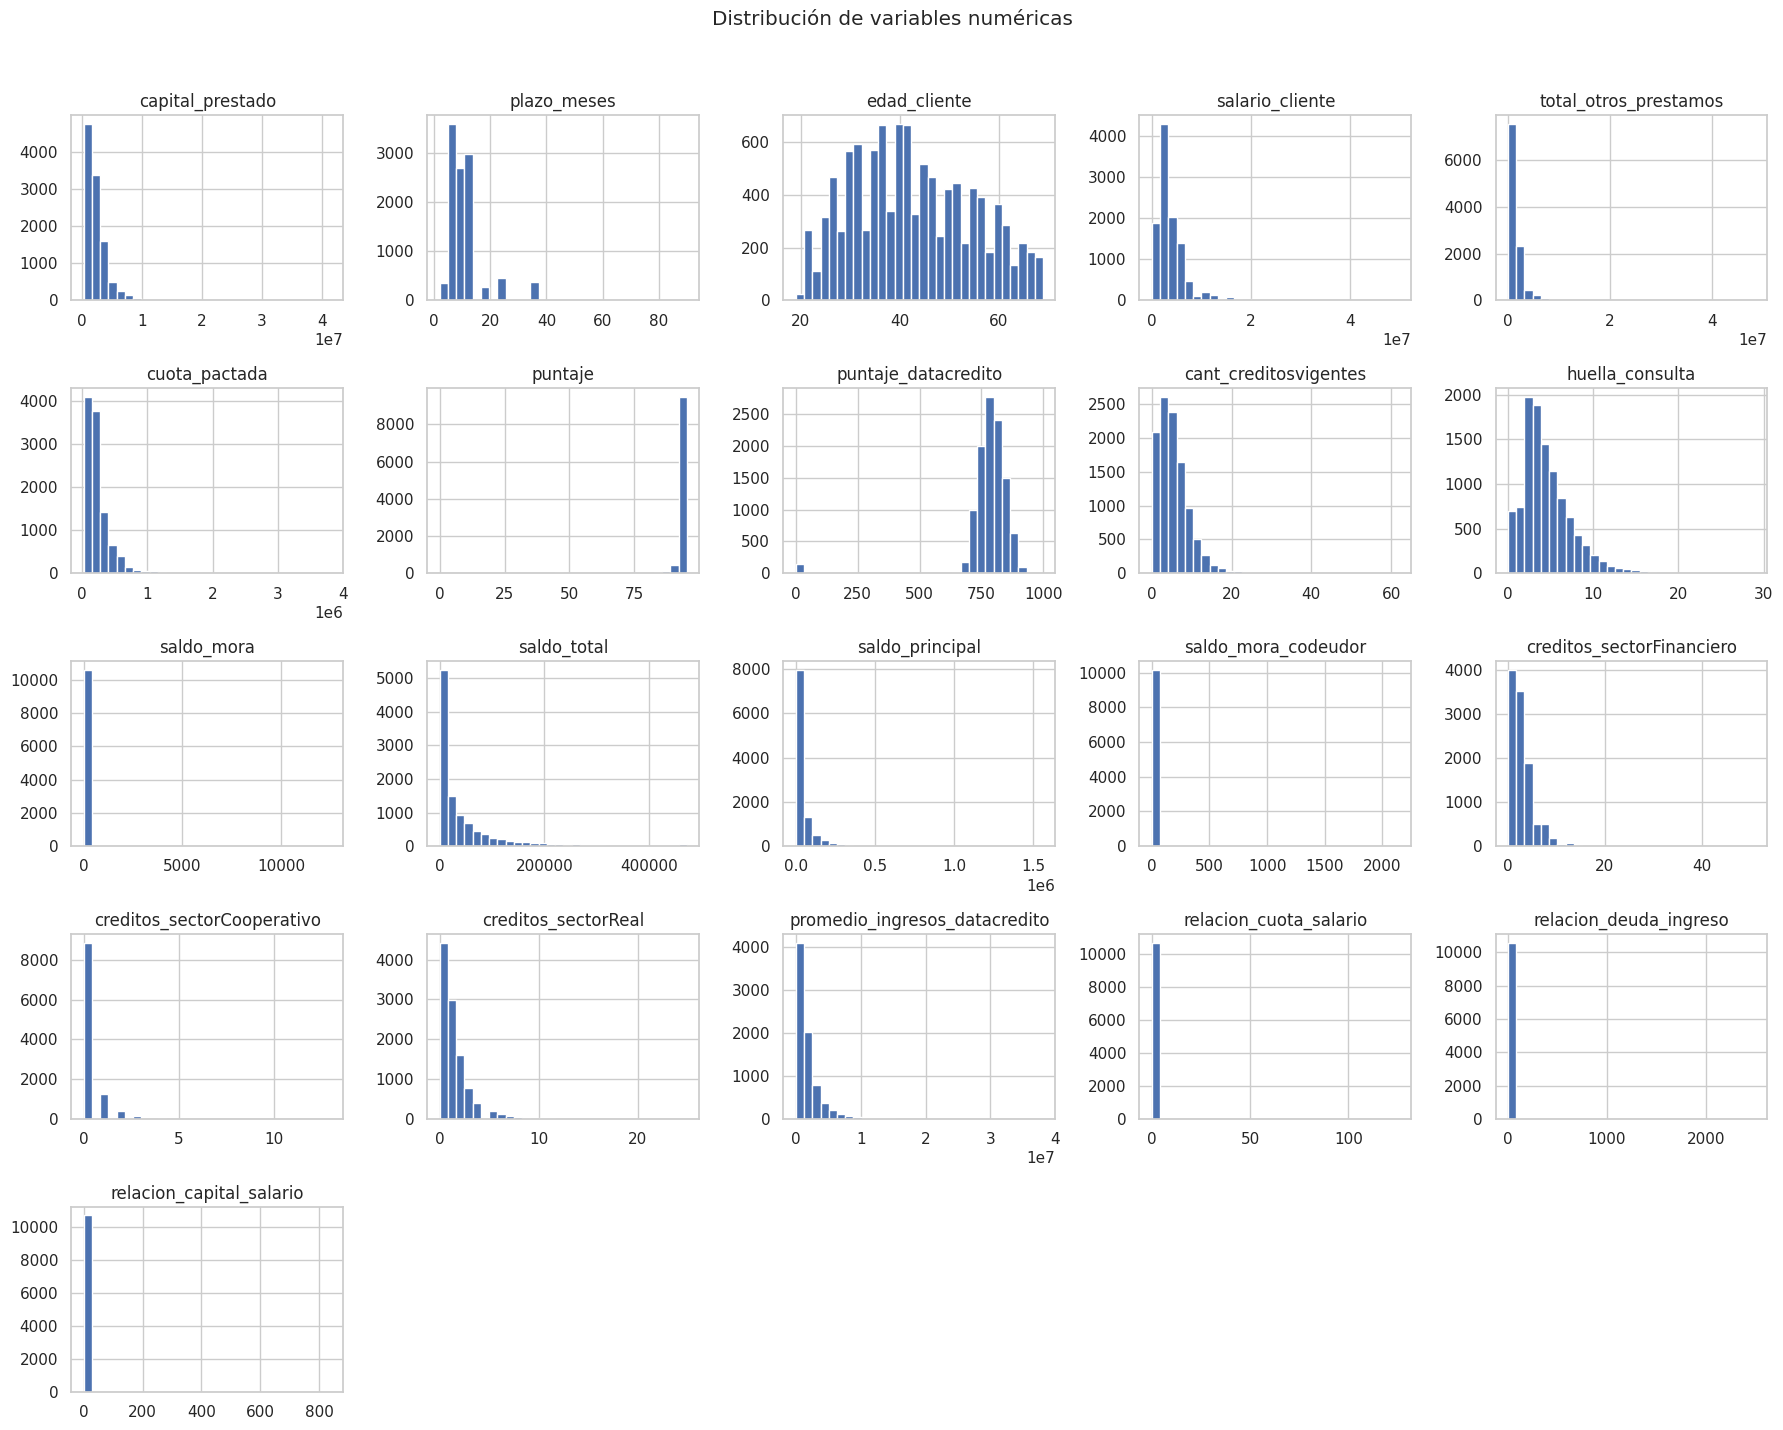

In [27]:
# Histogramas de todas las variables numéricas
df[cols_numericas].hist(bins=30, figsize=(18, 14))
plt.suptitle('Distribución de variables numéricas', y=1.02)
plt.tight_layout()
plt.show()

- **capital_prestado:** El capital prestado se concentra principalmente por debajo de 1 millón de pesos.
  *¿Qué significa esto?* La cartera analizada corresponde mayoritariamente a créditos de bajo monto (microcrédito o consumo pequeño), no a créditos de vivienda o comerciales de gran tamaño. Esto es coherente con la fuerte asimetría a la derecha detectada en el test de normalidad.

- **plazo_meses:** La mayoría de los clientes tiene créditos pactados a un plazo menor a 20 meses.
  *¿Qué significa esto?* Predominan los créditos de corto plazo, típicos de productos de consumo o rotativos, más que de créditos de largo plazo como hipotecarios.

- **edad_cliente:** La edad de los clientes va aproximadamente de los 20 a los 70 años, con una mayor concentración entre los 30 y los 50 años.
  *¿Qué significa esto?* La base de clientes se concentra en población económicamente activa y en edad laboral media, un perfil típico de acceso a crédito formal por tener ingresos más estables.

- **salario_cliente:** La mayoría de los clientes tiene un salario por debajo de 10.000.000 de pesos, pero también hay una gran cantidad de clientes con un salario de más de 10.000.000.
  *¿Qué significa esto?* Con la escala ya corregida, el histograma refleja de forma confiable la distribución real de ingresos de la cartera: predomina el segmento de salario bajo/medio (coherente con créditos de consumo pequeño), pero coexiste un grupo importante de salarios más altos. Esto indica que la base de clientes no es homogénea en ingresos, por lo que `salario_cliente` puede aportar valor real para diferenciar perfiles de riesgo (a diferencia de lo que sugería el histograma antes de corregir el error de escala).

- **total_otros_prestamos:** *(Nota: también corregido antes de graficar, en la sección 2.5.)* La mayoría de los clientes no tiene otros préstamos (el valor se concentra en 0), pero una gran cantidad de clientes sí tiene un total de otros préstamos, en un rango de 5.000.000 a 50.000.000.
  *¿Qué significa esto?* La mayoría de la cartera no tiene deuda adicional reportada, pero existe un segmento considerable con endeudamiento moderado por fuera del crédito analizado. Esto es relevante para el riesgo: un cliente con otros préstamos activos tiene menos capacidad de pago disponible, por lo que esta variable (ya limpia) es candidata a tener poder predictivo real sobre `Pago_atiempo`.

- **cuota_pactada:** La cuota mensual pactada para la mayoría de los clientes está por debajo de 1 millón de pesos.
  *¿Qué significa esto?* Es coherente con el capital prestado bajo: cuotas mensuales relativamente manejables para créditos pequeños.

- **puntaje:** La mayoría de los clientes tiene un puntaje superior a 80.
  *¿Qué significa esto?* Este resultado hay que tomarlo con cautela: ya identificamos que el 87% de los registros comparte exactamente el mismo valor (95.227787), que probablemente es un valor de relleno y no un score calculado individualmente. Por lo tanto, esta "mayoría por encima de 80" refleja en gran parte ese valor repetido, no diversidad real entre clientes.

- **puntaje_datacredito:** La mayoría de los clientes tiene un puntaje de Datacrédito superior a 600 y hasta 950. Además, hay un grupo de clientes que registra un puntaje de 0, lo que indica que no tienen puntaje crediticio calculado o no hay información suficiente para generarlo.
  *¿Qué significa esto?* En la escala de Datacrédito (150–950), los puntajes más altos reflejan un perfil de menor riesgo de incumplimiento según el historial crediticio. Que la mayoría esté entre 600 y 950 sugiere una base de clientes con buen historial crediticio previo. El grupo en 0 corresponde al "sentinela" que ya se identificó y se conservó marcado según lo definido en la sección 2.5, y no debe interpretarse como un puntaje real de riesgo alto.

- **cant_creditosvigentes:** La mayoría de los clientes tiene menos de 10 créditos vigentes.
  *¿Qué significa esto?* Indica un nivel de endeudamiento simultáneo moderado para la mayoría de la base.

- **huella_consulta:** La huella de consulta de la mayoría de los clientes está entre 2 y 5 aproximadamente.
  *¿Qué significa esto?* Representa cuántas veces se ha consultado el historial crediticio del cliente recientemente; un nivel moderado no sugiere, por sí solo, una búsqueda desesperada de crédito (señal que sí sería de riesgo si fuera muy alta).

- **saldo_mora:** Más de 10.000 clientes no registran saldo en mora.
  *¿Qué significa esto?* La gran mayoría de la base está al día con sus pagos en el momento de la foto de datos, lo cual es coherente con el desbalance de la variable objetivo hacia "paga a tiempo".

- **saldo_total:** La mayoría de los clientes (poco más de 10.000) tiene un saldo total menor a medio millón de pesos.
  *¿Qué significa esto?* La deuda total pendiente es baja para la mayoría, consistente con el perfil de créditos pequeños ya identificado.

- **saldo_principal:** El saldo principal de la mayoría de los clientes está por debajo de 250.000 pesos.
  *¿Qué significa esto?* Confirma el mismo patrón: el capital pendiente por pagar es bajo para la mayoría de los clientes.

- **saldo_mora_codeudor:** La mayoría de los clientes tiene un saldo de mora de codeudor cercano a 0.
  *¿Qué significa esto?* La mayoría de los créditos no tiene codeudor en mora, ya sea porque no tienen codeudor o porque el codeudor está al día.

- **creditos_sectorFinanciero:** La mayoría de los clientes tiene menos de 10 créditos con el sector financiero.
  *¿Qué significa esto?* Refleja un historial crediticio moderado dentro del sector financiero formal (bancos, entidades de crédito).

- **creditos_sectorCooperativo:** La mayoría de los clientes tiene menos de 2 créditos con el sector cooperativo; de hecho, la mayoría tiene 0.
  *¿Qué significa esto?* La participación de los clientes en el sector cooperativo es baja o nula, indicando que no es su canal principal de financiación.

- **creditos_sectorReal:** La mayoría de los clientes tiene menos de 5 créditos con el sector real (la mayoría tiene entre 0 y 3).
  *¿Qué significa esto?* La deuda con el sector real (comercio, tarjetas de almacén, etc.) también es baja para la mayoría de los clientes.

- **promedio_ingresos_datacredito:** El promedio de ingresos reportado a Datacrédito está por debajo de 10.000.000 de pesos para la mayoría de los clientes.
  *¿Qué significa esto?* Confirma un perfil de ingresos moderados en la base analizada, coherente con el tipo de créditos (montos y cuotas bajas) que predomina.

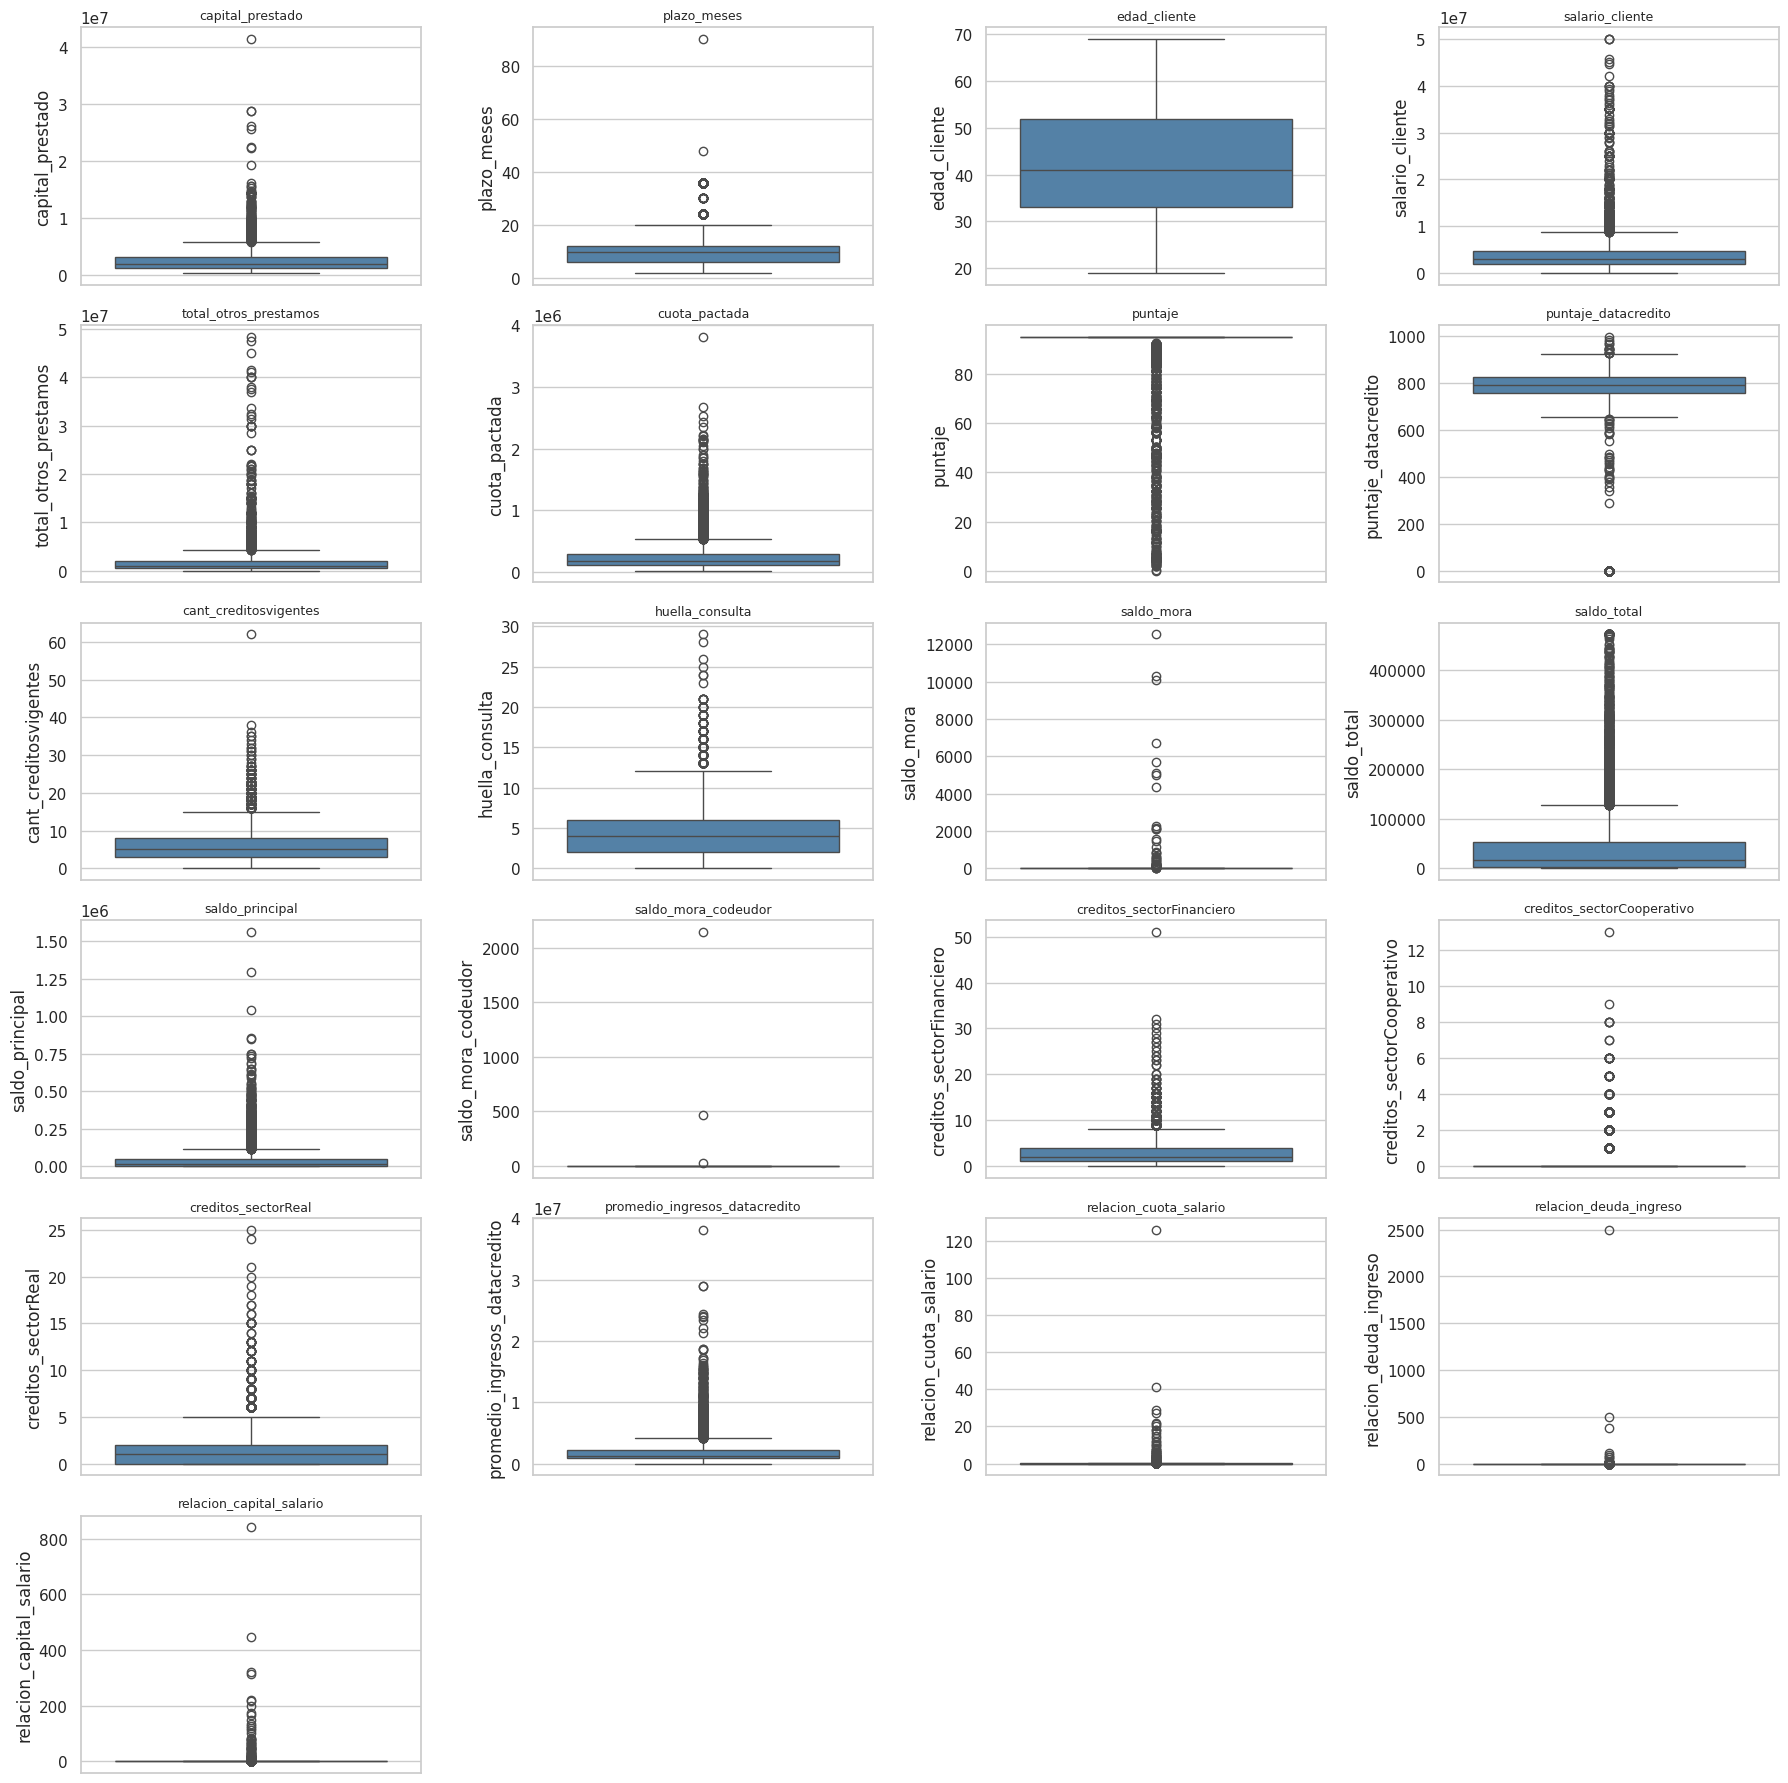

In [28]:
# Boxplots para identificar outliers
n_cols = 4
n_rows = int(np.ceil(len(cols_numericas) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*3))
axes = axes.flatten()
for i, c in enumerate(cols_numericas):
    sns.boxplot(y=df[c], ax=axes[i], color='steelblue')
    axes[i].set_title(c, fontsize=9)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

- **capital_prestado:** Hay un outlier de 40.000.000 en capital prestado; la mayoría de los valores se sitúan por debajo de los 30.000.000.
  *¿Qué significa esto?* Existe al menos un crédito de monto excepcionalmente alto frente al resto de la cartera; conviene revisar si es un cliente legítimo de perfil distinto o un error de captura.

- **plazo_meses:** Hay un outlier en plazo_meses de más de 80 meses; la mayoría se sitúa por debajo de los 60 meses.
  *¿Qué significa esto?* Ese plazo es inusualmente largo frente al resto de los créditos (recordemos que la mayoría son de menos de 20 meses), por lo que merece revisión puntual.

- **salario_cliente:** Se siguen observando algunos valores atípicos por encima del umbral de negocio usado para la corrección (\$50.000.000), pero ya en un orden de magnitud creíble para un salario, y no en miles de millones como antes de corregir la escala.
  *¿Qué significa esto?* Coherente con lo visto en el histograma: la mayoría de los clientes se concentra en salarios bajos/medios, con un grupo de clientes de salario alto que ahora aparece como outliers "normales" (no como error de captura). Estos sí deben revisarse caso a caso más adelante (¿son clientes legítimos de mejor perfil o aún queda algún error residual?), pero ya no distorsionan por sí solos ninguna estadística descriptiva de la variable.

- **total_otros_prestamos:** *(Nota: igualmente ya corregido.)* El patrón es similar al de `salario_cliente`: la mayoría de los clientes se concentra cerca de 0 (sin otros préstamos), con un grupo de valores atípicos por encima del umbral de negocio, pero ya dentro de un rango de decenas de millones de pesos, no de miles de millones.
  *¿Qué significa esto?* Refuerza la lectura del histograma: existe un segmento real de clientes con otros préstamos moderados a altos, y ya no hay evidencia de que la variable esté dominada por un error de escala. Estos outliers "genuinos" son justamente los que interesa analizar frente a `Pago_atiempo`, en vez de descartarlos como ruido.


- **cuota_pactada:** Hay un outlier en la cuota pactada de 4.000.000; la mayoría de los valores se sitúan por debajo de los 3.000.000.
  *¿Qué significa esto?* Refleja probablemente el mismo cliente/crédito del outlier de capital prestado (a mayor capital, mayor cuota), no un caso aislado distinto.

- **cant_creditosvigentes:** Hay un outlier en cant_creditosvigentes de más de 60 créditos vigentes; la mayoría se sitúa por debajo de 40.
  *¿Qué significa esto?* Un cliente con más de 60 créditos vigentes simultáneos es un caso atípico y potencialmente de alto riesgo o de error de captura; vale la pena inspeccionarlo individualmente.

- **creditos_sectorFinanciero:** Hay un outlier en creditos_sectorFinanciero de 50 créditos; la mayoría se sitúa por debajo de 45.
  *¿Qué significa esto?* Es un valor extremo, aunque cercano al resto de la distribución (a diferencia de otros outliers más alejados), por lo que su impacto en el análisis es menor.


In [29]:
# Test de normalidad (Shapiro, con muestra si el dataset es grande) para orientar el tipo de distribución
for c in cols_numericas:
    muestra = df[c].dropna()
    if len(muestra) > 5000:
        muestra = muestra.sample(5000, random_state=42)
    if len(muestra) > 3:
        stat, p = stats.shapiro(muestra)
        veredicto = 'No parece normal' if p < 0.05 else 'No se rechaza normalidad'
        print(f"{c}: p-valor={p:.4f} -> {veredicto}")

capital_prestado: p-valor=0.0000 -> No parece normal
plazo_meses: p-valor=0.0000 -> No parece normal
edad_cliente: p-valor=0.0000 -> No parece normal
salario_cliente: p-valor=0.0000 -> No parece normal
total_otros_prestamos: p-valor=0.0000 -> No parece normal
cuota_pactada: p-valor=0.0000 -> No parece normal
puntaje: p-valor=0.0000 -> No parece normal
puntaje_datacredito: p-valor=0.0000 -> No parece normal
cant_creditosvigentes: p-valor=0.0000 -> No parece normal
huella_consulta: p-valor=0.0000 -> No parece normal
saldo_mora: p-valor=0.0000 -> No parece normal
saldo_total: p-valor=0.0000 -> No parece normal
saldo_principal: p-valor=0.0000 -> No parece normal
saldo_mora_codeudor: p-valor=0.0000 -> No parece normal
creditos_sectorFinanciero: p-valor=0.0000 -> No parece normal
creditos_sectorCooperativo: p-valor=0.0000 -> No parece normal
creditos_sectorReal: p-valor=0.0000 -> No parece normal
promedio_ingresos_datacredito: p-valor=0.0000 -> No parece normal
relacion_cuota_salario: p-valo

**Interpretación:** ninguna variable numérica pasa el test de Shapiro-Wilk (todos los p-valores ≈ 0), es decir, ninguna sigue una distribución normal. Esto es esperable en datos financieros/crediticios: las variables monetarias (`capital_prestado`, `salario_cliente`, `saldo_total`, etc.) suelen ser fuertemente asimétricas a la derecha (muchos valores bajos/medios y una cola de valores altos), y las variables de conteo (`cant_creditosvigentes`, `huella_consulta`, `creditos_sectorFinanciero`, etc.) son discretas y con muchos ceros.

Consecuencias prácticas para el resto del análisis y el futuro modelado:
- Usar **mediana e IQR** (no media y desviación estándar) como medidas de tendencia central/dispersión "resumen", ya que son más robustas a la asimetría.
- Considerar **transformaciones** (log, log1p, Box-Cox) para las variables monetarias muy sesgadas antes de usarlas en modelos sensibles a la escala/normalidad (regresión lineal, regresión logística sin regularización).
- Para pruebas de hipótesis posteriores (por ejemplo, comparar grupos de `Pago_atiempo`), preferir pruebas **no paramétricas** en vez de t-test.
- Modelos basados en árboles (Random Forest, XGBoost, LightGBM) no requieren normalidad, por lo que este hallazgo no los penaliza directamente.


/tmp/ipykernel_1893/2980349781.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[c], ax=ax, palette='viridis')
/tmp/ipykernel_1893/2980349781.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[c], ax=ax, palette='viridis')
/tmp/ipykernel_1893/2980349781.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[c], ax=ax, palette='viridis')
/tmp/ipykernel_1893/2980349781.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `leg

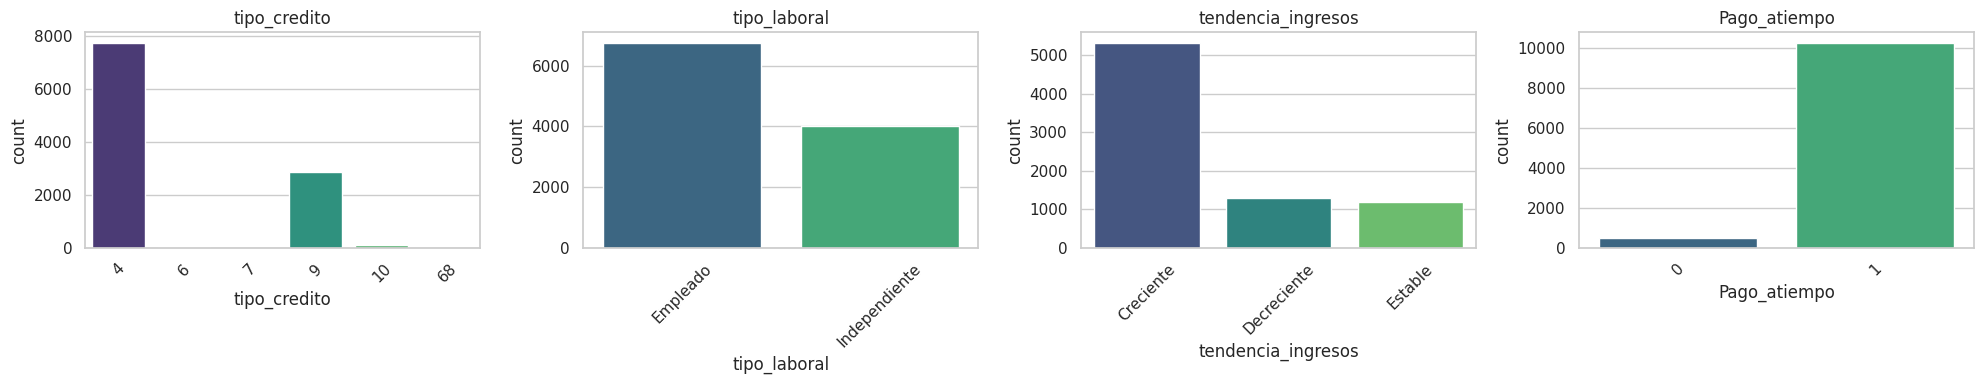


--- tipo_credito ---
tipo_credito
4     7747
9     2876
10     116
6       21
7        2
68       1
Name: count, dtype: int64
tipo_credito
4     71.98 %
9     26.72 %
10     1.08 %
6       0.2 %
7      0.02 %
68     0.01 %
Name: proportion, dtype: object

--- tipo_laboral ---
tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64
tipo_laboral
Empleado         62.75 %
Independiente    37.25 %
Name: proportion, dtype: object

--- tendencia_ingresos ---
tendencia_ingresos
Creciente      5335
Decreciente    1301
Estable        1195
Name: count, dtype: int64
tendencia_ingresos
Creciente      68.13 %
Decreciente    16.61 %
Estable        15.26 %
Name: proportion, dtype: object

--- Pago_atiempo ---
Pago_atiempo
1    10252
0      511
Name: count, dtype: int64
Pago_atiempo
1    95.25 %
0     4.75 %
Name: proportion, dtype: object


In [30]:
cols_categoricas_plot = df.select_dtypes(include='category').columns.tolist()

fig, axes = plt.subplots(1, len(cols_categoricas_plot), figsize=(5*len(cols_categoricas_plot), 4))
if len(cols_categoricas_plot) == 1:
    axes = [axes]
for ax, c in zip(axes, cols_categoricas_plot):
    sns.countplot(x=df[c], ax=ax, palette='viridis')
    ax.set_title(c)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

for c in cols_categoricas_plot:
    print(f"\n--- {c} ---")
    print(df[c].value_counts())
    print((df[c].value_counts(normalize=True) * 100).round(2).astype(str) + ' %')



- **tipo_credito:** La mayoría de los créditos son de la categoría 4, seguida por la categoría 9.
  *¿Qué significa esto?* Estos dos tipos de crédito concentran la mayor parte de la cartera y merecen atención prioritaria en el análisis de riesgo.

- **tipo_laboral:** La mayoría de los clientes son empleados, seguidos por los independientes.
  *¿Qué significa esto?* El perfil laboral predominante tiene ingresos formales y más verificables, lo cual suele asociarse a menor riesgo de incumplimiento.

- **tendencia_ingresos:** La tendencia de ingresos de los clientes es, en su mayoría, creciente.
  *¿Qué significa esto?* La mayoría de los clientes muestra una situación de ingresos en mejora, lo cual es una señal positiva para la capacidad de pago futura.

- **Pago_atiempo (balance de la variable objetivo):** La gran mayoría de los clientes paga a tiempo (aproximadamente 10.000), mientras que la categoría de "no paga a tiempo" tiene muy pocos datos. Si se quisiera construir un modelo predictivo, es recomendable aplicar *undersampling* sobre la clase mayoritaria.
  *¿Qué significa esto?* Hay un fuerte desbalance de clases. Entrenar un modelo directamente sobre estos datos generaría un sesgo hacia predecir siempre "paga a tiempo", con muy baja capacidad de detectar el riesgo real de mora. Además del undersampling, también podrían evaluarse alternativas como oversampling (SMOTE) o el uso de métricas como F1/recall en vez de accuracy.


### 3.2 Análisis bivariable
Relación de cada variable con la variable objetivo `Pago_atiempo`.


Pago_atiempo
1    10252
0      511
Name: count, dtype: int64
Pago_atiempo
1    95.25
0     4.75
Name: proportion, dtype: float64


/tmp/ipykernel_1893/137243680.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[target], palette='Set2')


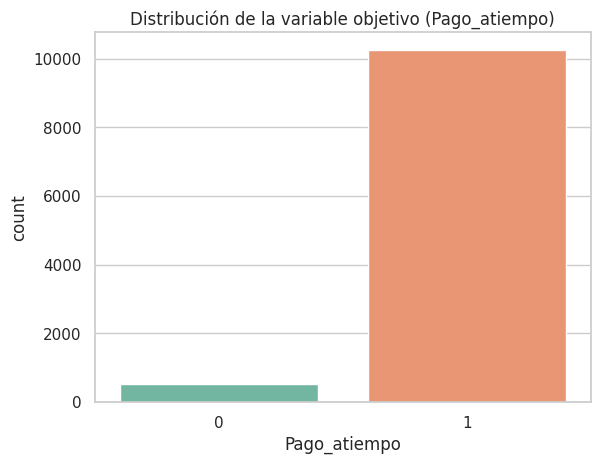

In [31]:
target = 'Pago_atiempo'

# Balance de la variable objetivo
print(df[target].value_counts())
print((df[target].value_counts(normalize=True) * 100).round(2))

sns.countplot(x=df[target], palette='Set2')
plt.title('Distribución de la variable objetivo (Pago_atiempo)')
plt.show()

/tmp/ipykernel_1893/3329432565.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[c], ax=axes[i], palette='Set2')
/tmp/ipykernel_1893/3329432565.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[c], ax=axes[i], palette='Set2')
/tmp/ipykernel_1893/3329432565.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[c], ax=axes[i], palette='Set2')
/tmp/ipykernel_1893/3329432565.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Ass

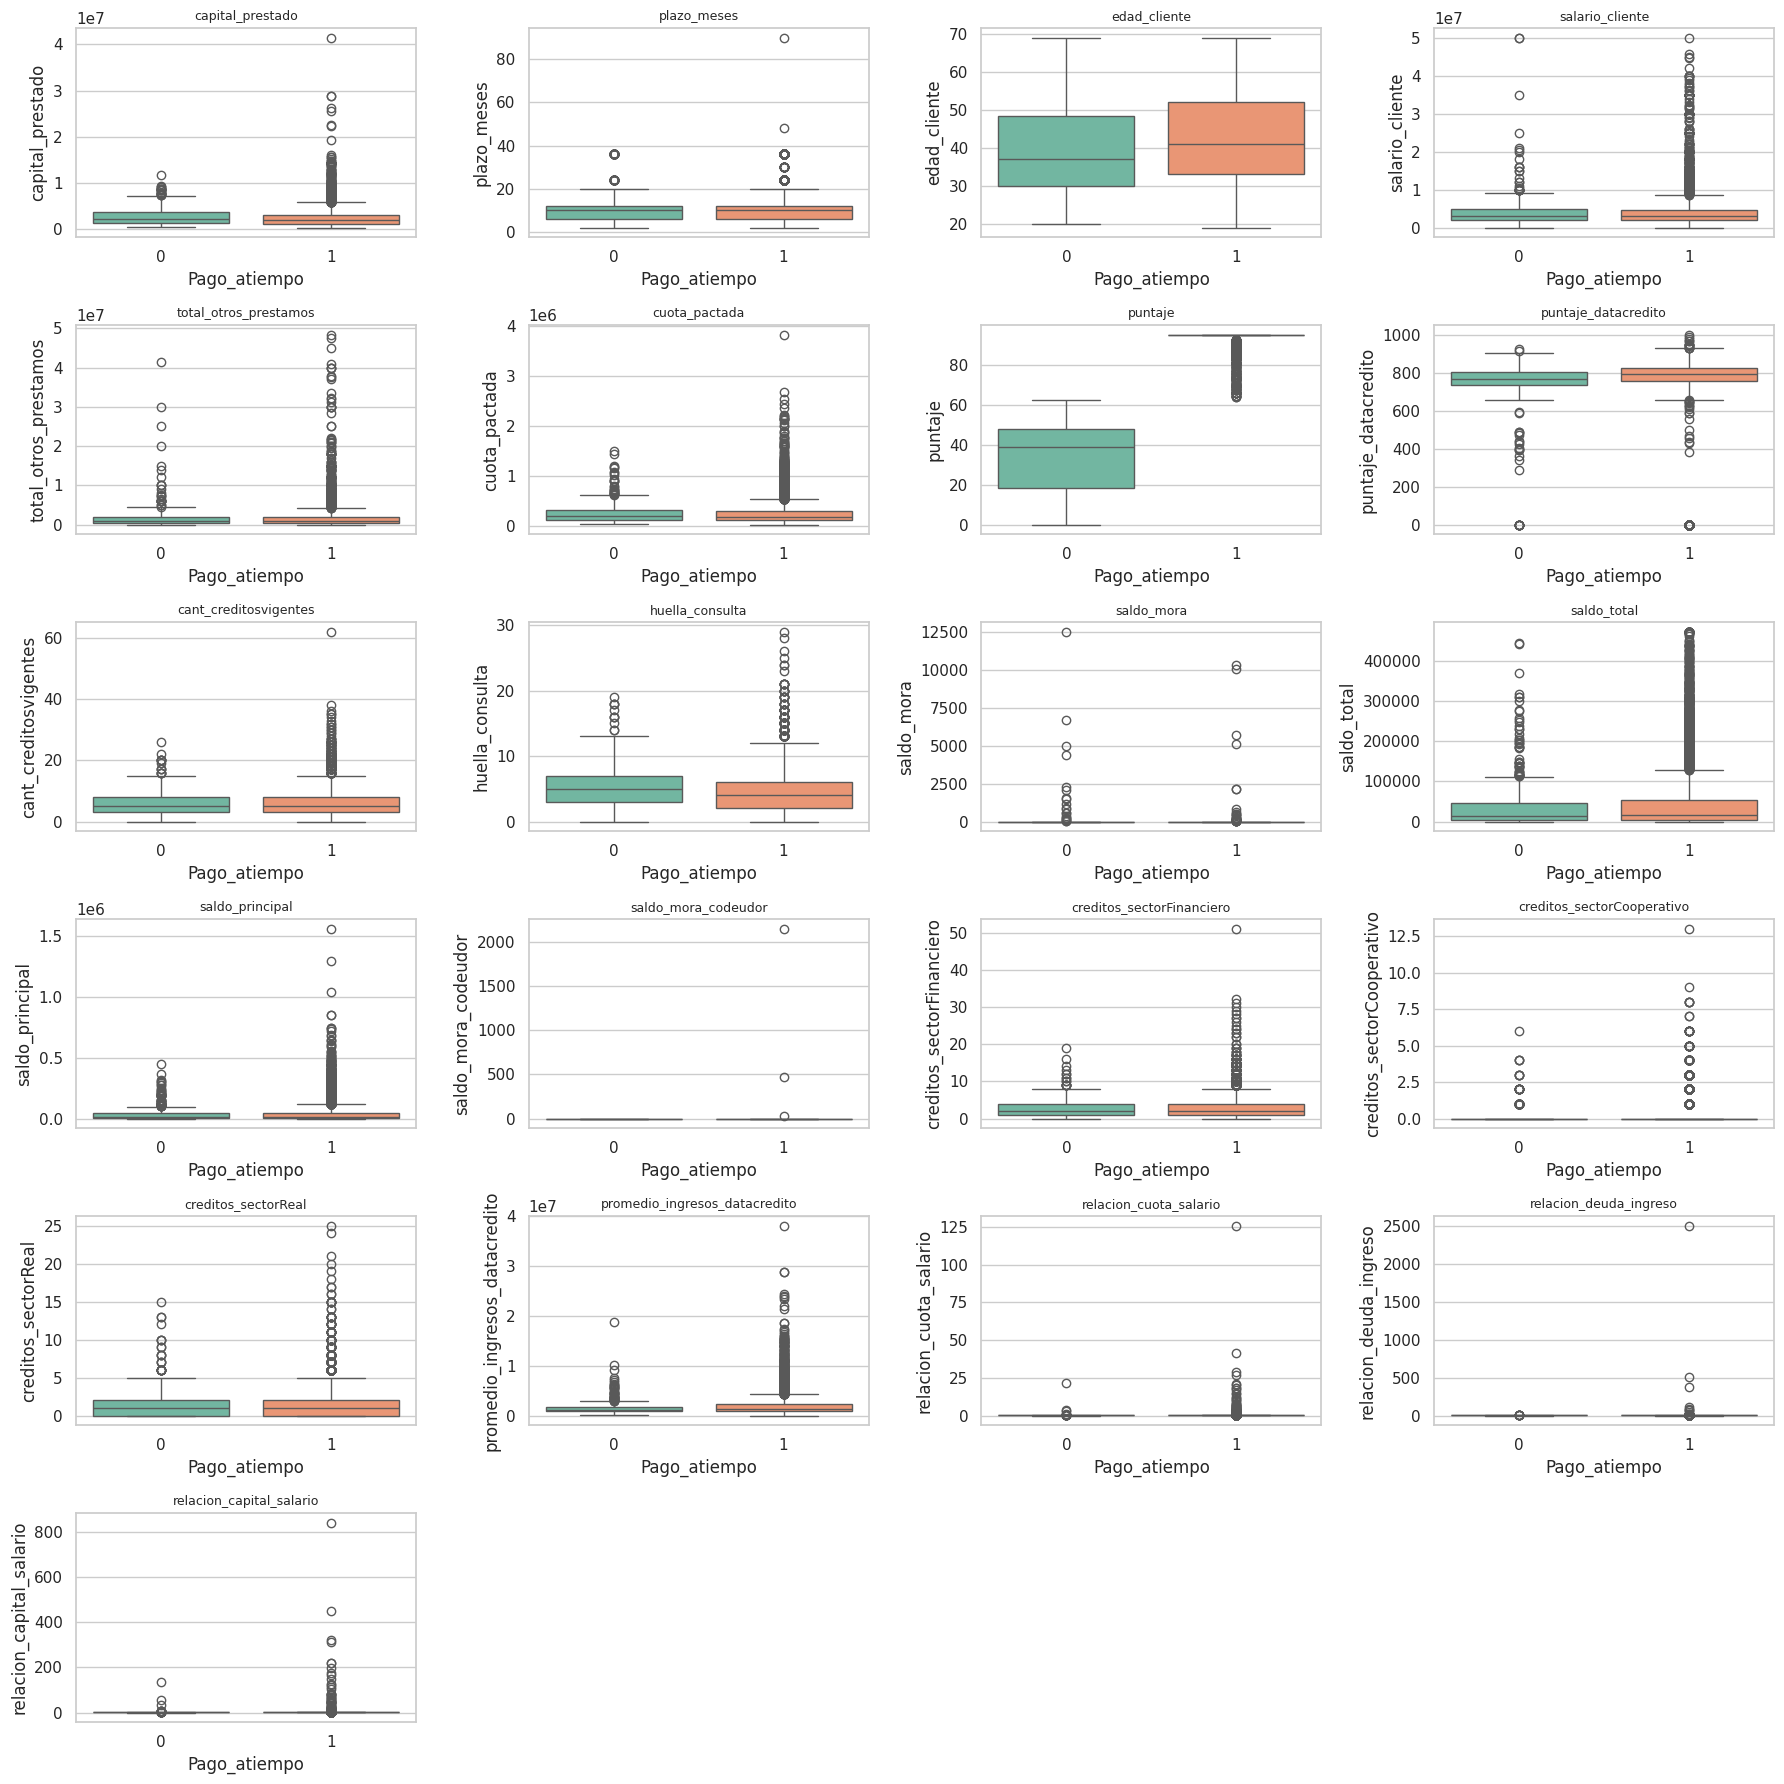

In [32]:
# Numéricas vs. objetivo: boxplots comparativos
n_cols = 4
n_rows = int(np.ceil(len(cols_numericas) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*3))
axes = axes.flatten()
for i, c in enumerate(cols_numericas):
    sns.boxplot(x=df[target], y=df[c], ax=axes[i], palette='Set2')
    axes[i].set_title(c, fontsize=9)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

- **capital_prestado:** Las personas que pagan a tiempo tienen un rango más amplio de capital prestado (hasta 40.000.000), mientras que el valor máximo entre quienes no pagan a tiempo es menor a 20.000.000.
  *¿Qué significa esto?* Los créditos de mayor monto parecen concentrarse en clientes que sí cumplen con el pago, posiblemente porque el proceso de aprobación de créditos grandes ya filtra a los clientes de mejor perfil.

- **plazo_meses:** El plazo de meses es similar entre quienes pagan a tiempo y quienes no, a excepción del outlier de más de 80 meses (presente solo en el grupo que paga a tiempo).
  *¿Qué significa esto?* El plazo del crédito, por sí solo, no parece diferenciar fuertemente entre buenos y malos pagadores en esta base.

- **salario_cliente:** Hay mayor cantidad de clientes que pagan a tiempo cuyo salario está entre los 10.000.000 y los 50.000.000; ese mismo rango también aparece entre quienes no pagan a tiempo, pero en menor cantidad.
  *¿Qué significa esto?* Con la escala corregida, la comparación ya es confiable: un salario medio-alto (10 a 50 millones) está presente en ambos grupos, pero es proporcionalmente más frecuente entre los buenos pagadores. Esto sugiere que un mayor salario se asocia con menor riesgo de mora, aunque el patrón no es exclusivo —también hay clientes de ese mismo rango salarial que caen en mora—, por lo que `salario_cliente` aporta señal de riesgo, pero no basta por sí sola y debe combinarse con otras variables (capital prestado, cuota pactada, historial crediticio).

- **cuota_pactada:** Las personas que pagan a tiempo suelen tener una cuota pactada mayor.
  *¿Qué significa esto?* Es coherente con el hallazgo de capital prestado: quienes pagan a tiempo tienden a tener créditos más grandes y, por tanto, cuotas más altas.

- **total_otros_prestamos:** Hay mayor cantidad de clientes que pagan a tiempo cuyo total de otros préstamos está entre 5.000.000 y 50.000.000; esto también ocurre entre quienes no pagan a tiempo, pero no son tantos.
  *¿Qué significa esto?* Ya sin el error de escala, se observa que tener otros préstamos en un rango moderado a alto (5 a 50 millones) es más común entre los clientes que sí pagan a tiempo. Esto puede reflejar que se trata de clientes con un perfil crediticio más establecido y con mayor capacidad de acceso y manejo de crédito, más que un simple indicador de sobreendeudamiento. Como el mismo patrón aparece (en menor proporción) también entre quienes no pagan, esta variable debe interpretarse junto con otras (por ejemplo, `salario_cliente` o `puntaje_datacredito`) antes de sacar conclusiones definitivas sobre el riesgo.

- **puntaje:** Las personas que pagan a tiempo son, en su mayoría, las que tienen el puntaje de 95.222 (el valor que se identificó como insertado/repetido en varios registros).
  *¿Qué significa esto?* Esto reafirma la sospecha de que `puntaje` no es un score genuino por cliente, sino un valor de relleno que coincide más con los clientes que pagan a tiempo. Esta variable debe usarse con mucho cuidado en un futuro modelo, ya que podría introducir una fuga de información (*data leakage*) artificial en vez de una relación real.

- **puntaje_datacredito:** Las personas que pagan a tiempo y las que no pagan a tiempo tienen una distribución similar en el puntaje de Datacrédito.
  *¿Qué significa esto?* Es un resultado interesante y algo contraintuitivo: se esperaría que el puntaje de Datacrédito, al ser una medida de riesgo crediticio, discriminara claramente entre buenos y malos pagadores. Que las distribuciones sean similares sugiere que, en esta base específica, esta variable por sí sola tiene menor poder predictivo del esperado, y quizás deba combinarse con otras variables o revisarse su calidad de captura.

- **cant_creditosvigentes:** Las personas que pagan a tiempo tienen mayor cantidad de créditos vigentes que las que no pagan a tiempo.
  *¿Qué significa esto?* Aunque podría parecer contraintuitivo (más deuda = más riesgo), en la práctica puede reflejar que estos clientes tienen un historial crediticio más largo y ya han sido aprobados repetidamente, lo que en algunos modelos de riesgo se interpreta como una señal de confiabilidad.

- **huella_consulta:** Las personas que pagan a tiempo tienen mayor huella de consulta que las que no pagan a tiempo.
  *¿Qué significa esto?* De forma similar al punto anterior, un número mayor de consultas puede reflejar mayor actividad crediticia histórica de un cliente ya establecido, más que una búsqueda urgente de crédito (que normalmente sí sería señal de riesgo).

- **saldo_mora:** Ambos grupos tienen un saldo de mora similar, salvo por un valor cercano a 12.500 presente en el grupo que no paga a tiempo.
  *¿Qué significa esto?* Es coherente que el grupo en mora presente el valor más alto de saldo en mora; tiene sentido de negocio y valida parcialmente la calidad de esta variable.

- **saldo_total:** Las personas que pagan a tiempo tienden a tener un saldo total mayor.
  *¿Qué significa esto?* Puede reflejar mayor capacidad de endeudamiento o mejores condiciones de crédito otorgadas a este grupo.

- **saldo_principal:** Las personas que pagan a tiempo tienden a tener un saldo principal mayor.
  *¿Qué significa esto?* Es coherente con el hallazgo anterior sobre saldo total.

- **saldo_mora_codeudor:** La mayoría de los clientes no registra saldo de mora de codeudor.
  *¿Qué significa esto?* Esta variable tiene muy poca variabilidad en general, por lo que su capacidad para diferenciar entre grupos de pago es limitada.

- **creditos_sectorFinanciero:** Los clientes que pagan a tiempo tienen más créditos en el sector financiero que los que no pagan a tiempo.
  *¿Qué significa esto?* Un historial más extenso en el sector financiero formal se asocia con mejor comportamiento de pago.

- **creditos_sectorCooperativo:** No hay una diferencia notable entre quienes pagan a tiempo y quienes no en la cantidad de créditos del sector cooperativo.
  *¿Qué significa esto?* Esta variable parece tener poco poder discriminante frente a la variable objetivo.

- **creditos_sectorReal:** Los clientes que pagan a tiempo tienen más créditos en el sector real que los que no pagan a tiempo.
  *¿Qué significa esto?* Similar al hallazgo del sector financiero: mayor historial crediticio general se asocia con mejor comportamiento de pago.

- **promedio_ingresos_datacredito:** Los clientes que pagan a tiempo tienen un promedio de ingresos según Datacrédito mayor (más de 20.000.000) que los que no pagan a tiempo.
  *¿Qué significa esto?* Tiene sentido de negocio: a mayor ingreso reportado, mayor capacidad de pago y menor probabilidad de caer en mora.

**Profundizando en los hallazgos anteriores**

Los boxplots anteriores dejaron tres afirmaciones planteadas pero no verificadas con un análisis adicional: que `salario_cliente` "aporta señal pero no basta por sí sola y debe combinarse con otras variables", que `total_otros_prestamos` "debe interpretarse junto con `salario_cliente` o `puntaje_datacredito`", y que `puntaje_datacredito` "quizás deba revisarse su calidad de captura".

In [33]:
# --- ¿'salario_cliente' aporta señal real y se refuerza al combinarla con otras variables? ---

# 1) Fuerza de la relación individual con el target
r_salario, p_salario = stats.pointbiserialr(df[target].astype(int), df['salario_cliente'])
print(f"salario_cliente vs {target}: r punto-biserial = {r_salario:.3f} (p = {p_salario:.4f})")

# 2) ¿La señal se refuerza al combinarla con capital_prestado/cuota_pactada (via relacion_cuota_salario)?
df_temp = df.copy()
df_temp['salario_rango'] = pd.cut(
    df_temp['salario_cliente'], bins=[0, 10_000_000, 50_000_000, np.inf],
    labels=['<10M', '10M-50M', '>50M']
)
df_temp['relacion_cuota_rango'] = pd.qcut(
    df_temp['relacion_cuota_salario'], 3, labels=['baja', 'media', 'alta'], duplicates='drop'
)

tabla_salario = df_temp.pivot_table(
    index='salario_rango', columns='relacion_cuota_rango',
    values=target, aggfunc=lambda s: (s.astype(int) == 0).mean() * 100
)
print("\nTasa de mora (%) por rango de salario y nivel de relación cuota/salario:")
print(tabla_salario.round(2))

salario_cliente vs Pago_atiempo: r punto-biserial = -0.009 (p = 0.3752)

Tasa de mora (%) por rango de salario y nivel de relación cuota/salario:
relacion_cuota_rango  baja  media  alta
salario_rango                          
<10M                  4.43   4.86  5.00
10M-50M               3.95   5.26  4.35


/tmp/ipykernel_1893/1885107386.py:17: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabla_salario = df_temp.pivot_table(


**Resultado:** correlación punto-biserial prácticamente nula y no significativa (r = -0.009, p = 0.375). En la tabla cruzada, la tasa de mora se mantiene en un rango muy estrecho (3.95%–5.26%), sin importar el rango de salario ni el nivel de `relacion_cuota_salario`.

*¿Qué significa esto?* Contrario a lo que sugería la lectura visual del boxplot, `salario_cliente` —sola o combinada con `relacion_cuota_salario`— **no muestra una relación estadísticamente significativa** con `Pago_atiempo` en esta base. La diferencia que parecía verse en el boxplot (más clientes de salario medio-alto entre los que pagan a tiempo) probablemente refleja que hay más clientes de ese rango salarial en el dataset en general, no que el salario por sí mismo discrimine el riesgo.

In [34]:
# --- ¿'total_otros_prestamos' se interpreta mejor junto con 'salario_cliente'? ---

r_otros, p_otros = stats.pointbiserialr(df[target].astype(int), df['total_otros_prestamos'])
print(f"total_otros_prestamos vs {target}: r punto-biserial = {r_otros:.3f} (p = {p_otros:.4f})")

df_temp['otros_prestamos_rango'] = pd.cut(
    df_temp['total_otros_prestamos'], bins=[-0.01, 0, 5_000_000, 50_000_000, np.inf],
    labels=['0', '0-5M', '5M-50M', '>50M']
)

tabla_otros = df_temp.pivot_table(
    index='otros_prestamos_rango', columns='salario_rango',
    values=target, aggfunc=lambda s: (s.astype(int) == 0).mean() * 100
)
print("\nTasa de mora (%) por rango de total_otros_prestamos y rango de salario:")
print(tabla_otros.round(2))

total_otros_prestamos vs Pago_atiempo: r punto-biserial = -0.005 (p = 0.6233)

Tasa de mora (%) por rango de total_otros_prestamos y rango de salario:
salario_rango          <10M  10M-50M
otros_prestamos_rango               
0                      9.44     7.69
0-5M                   4.53     2.51
5M-50M                 7.86     5.41


/tmp/ipykernel_1893/2075875303.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabla_otros = df_temp.pivot_table(


**Resultado:** correlación punto-biserial también prácticamente nula y no significativa (r = -0.005, p = 0.623). La tabla cruzada por rango de otros préstamos y rango de salario no muestra un patrón consistente (va de 2.51% a 9.44% sin un orden claro).

*¿Qué significa esto?* Igual que con `salario_cliente`, la hipótesis original no se sostiene: combinar `total_otros_prestamos` con `salario_cliente` no revela una relación clara con el riesgo de mora. Las variaciones de la tabla cruzada parecen ruido más que un patrón real — no hay una tendencia consistente de que más o menos deuda adicional se asocie con mayor o menor mora.

In [35]:
# --- ¿'puntaje_datacredito' tiene un problema de calidad de captura como el de 'puntaje'? ---

print("Valores más frecuentes de puntaje_datacredito (posible valor de relleno):")
print((df['puntaje_datacredito'].value_counts(normalize=True).head(5) * 100).round(2))

print(f"\n% de registros en el sentinela 0 ('sin puntaje Datacrédito'): "
      f"{(df['puntaje_datacredito'] == 0).mean() * 100:.2f}%")
print(f"Valores únicos: {df['puntaje_datacredito'].nunique()}")

# ¿Las distribuciones son realmente distintas entre los dos grupos, o solo lo parecen en el boxplot?
grupo_mora = df.loc[df[target].astype(int) == 0, 'puntaje_datacredito'].dropna()
grupo_al_dia = df.loc[df[target].astype(int) == 1, 'puntaje_datacredito'].dropna()
u_stat, p_valor = stats.mannwhitneyu(grupo_mora, grupo_al_dia)
print(f"\nMann-Whitney U: estadístico = {u_stat:.1f}, p-valor = {p_valor:.4f}")

df_r = df[[target, 'puntaje_datacredito']].dropna()
r_puntaje_dc, p_r = stats.pointbiserialr(df_r[target].astype(int), df_r['puntaje_datacredito'])
print(f"puntaje_datacredito vs {target}: r punto-biserial = {r_puntaje_dc:.3f} (p = {p_r:.4f})")

Valores más frecuentes de puntaje_datacredito (posible valor de relleno):
puntaje_datacredito
0.0      1.35
783.0    0.95
802.0    0.95
791.0    0.93
804.0    0.91
Name: proportion, dtype: float64

% de registros en el sentinela 0 ('sin puntaje Datacrédito'): 1.35%
Valores únicos: 313

Mann-Whitney U: estadístico = 1968706.5, p-valor = 0.0000
puntaje_datacredito vs Pago_atiempo: r punto-biserial = 0.069 (p = 0.0000)


**Resultado — calidad de captura:** no hay evidencia de un valor de relleno dominante como el de `puntaje`. El valor más frecuente es apenas 1.35% de los registros (el sentinela 0, ya documentado como "sin información Datacrédito"), con 313 valores únicos razonablemente dispersos. **Se descarta la sospecha de mala calidad de captura** planteada originalmente — `puntaje_datacredito` sí parece un score genuino, no un placeholder.

**Resultado — magnitud de la relación:** r = 0.069 (p < 0.0001).

¿Qué significa esto? Confirma lo que ya insinuaba el Mann-Whitney: la diferencia entre grupos es real, no es casualidad estadística. Pero el tamaño del efecto es prácticamente insignificante — un r de 0.069 está muy por debajo de lo que se considera una correlación débil (convencionalmente, <0.1 se trata como despreciable). Es el patrón típico de un dataset grande: con suficientes observaciones, hasta una diferencia mínima se vuelve "estadísticamente significativa", pero eso no la vuelve útil en la práctica.

En conjunto, se corrige la interpretación original: puntaje_datacredito no tiene un problema de calidad de captura (eso se descartó), pero tampoco es el predictor fuerte que se esperaría de un score de riesgo crediticio — su relación individual con Pago_atiempo es real pero marginal. Igual que salario_cliente y total_otros_prestamos, no aporta señal relevante por sí sola; si tiene algún valor, probablemente sea en combinación con otras variables dentro de un modelo (no de forma aislada como se probó).

In [36]:
# Tabla pivote: promedio de cada variable numérica según Pago_atiempo
df.pivot_table(index=target, values=cols_numericas, aggfunc='mean').T

/tmp/ipykernel_1893/113123607.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index=target, values=cols_numericas, aggfunc='mean').T


Pago_atiempo,0,1
cant_creditosvigentes,5.569472e+00,5.734588e+00
capital_prestado,2.781774e+06,2.416996e+06
creditos_sectorCooperativo,2.015656e-01,2.732150e-01
creditos_sectorFinanciero,2.516634e+00,2.793114e+00
creditos_sectorReal,1.493151e+00,1.293211e+00
cuota_pactada,2.547557e+05,2.430622e+05
edad_cliente,3.962035e+01,4.270123e+01
huella_consulta,5.240705e+00,4.178112e+00
plazo_meses,1.245010e+01,1.048215e+01
promedio_ingresos_datacredito,1.605742e+06,2.023448e+06


- **Mayor en promedio entre quienes pagan a tiempo:** `cant_creditosvigentes`, `creditos_sectorCooperativo`, `creditos_sectorFinanciero`, `edad_cliente`, `saldo_principal`, `promedio_ingresos_datacredito`, `puntaje`, `puntaje_datacredito`, `saldo_mora_codeudor`, `saldo_total`, `total_otros_prestamos`.
  *¿Qué significa esto?* En promedio, este grupo se asocia con clientes de mayor historial y profundidad crediticia (más créditos, más antigüedad, mayores ingresos reportados), lo cual es coherente con un perfil de menor riesgo.

- **Mayor en promedio entre quienes no pagan a tiempo:** `capital_prestado`, `creditos_sectorReal`, `cuota_pactada`, `huella_consulta`, `plazo_meses`, `salario_cliente`, `saldo_mora`.
  *¿Qué significa esto?* Este grupo se asocia con créditos de mayor monto y cuota relativa a su perfil, lo cual es un patrón clásico de riesgo: cuando el monto o la cuota pactada es alto en relación con la capacidad real del cliente, aumenta la probabilidad de incumplimiento.


--- tipo_credito vs Pago_atiempo (% por fila) ---
Pago_atiempo      0       1
tipo_credito               
4              4.69   95.31
6             42.86   57.14
7              0.00  100.00
9              4.73   95.27
10             2.59   97.41
68             0.00  100.00


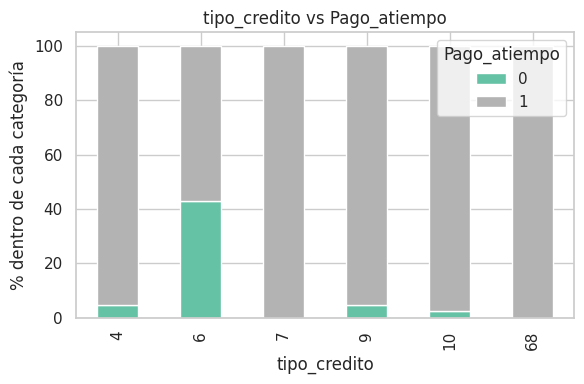


--- tipo_laboral vs Pago_atiempo (% por fila) ---
Pago_atiempo      0      1
tipo_laboral              
Empleado       4.29  95.71
Independiente  5.51  94.49


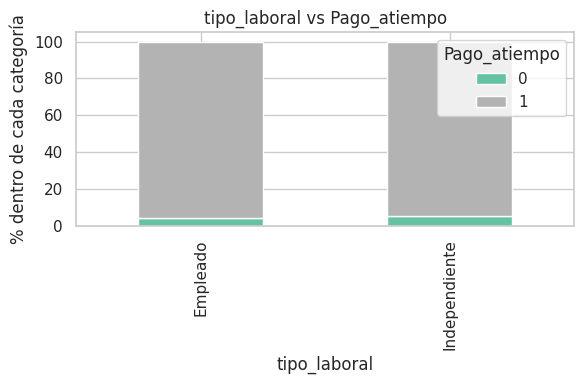


--- tendencia_ingresos vs Pago_atiempo (% por fila) ---
Pago_atiempo           0      1
tendencia_ingresos             
Creciente           3.88  96.12
Decreciente         6.23  93.77
Estable             4.60  95.40


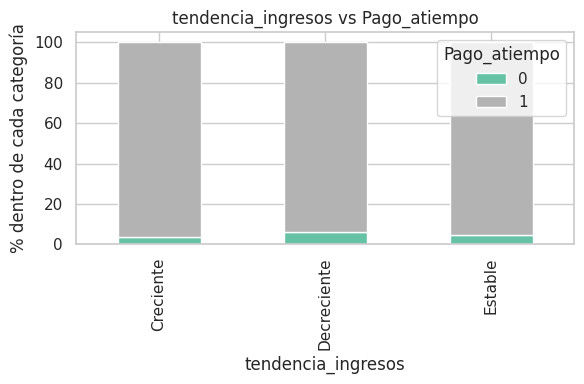

In [37]:
# Categóricas vs. objetivo: tabla cruzada y gráfico
cols_cat_sin_target = [c for c in cols_categoricas_plot if c != target]

for c in cols_cat_sin_target:
    tabla = pd.crosstab(df[c], df[target], normalize='index') * 100
    print(f"\n--- {c} vs {target} (% por fila) ---")
    print(tabla.round(2))

    tabla.plot(kind='bar', stacked=True, figsize=(6, 4), colormap='Set2')
    plt.title(f'{c} vs {target}')
    plt.ylabel('% dentro de cada categoría')
    plt.legend(title=target)
    plt.tight_layout()
    plt.show()

- **tipo_credito:** Las personas que pagan a tiempo tienen más créditos de tipo 4, 7, 9, 10 y 68. En cambio, quienes no pagan a tiempo se asocian más con el crédito tipo 6.
  *¿Qué significa esto?* El tipo de crédito 6 parece ser un producto de mayor riesgo relativo dentro de la cartera y podría convertirse en una variable categórica útil para el modelo de predicción de mora.

- **tipo_laboral:** Tanto empleados como independientes están representados entre quienes pagan a tiempo.
  *¿Qué significa esto?* El tipo laboral, por sí solo, no parece ser un diferenciador fuerte del comportamiento de pago en esta base; convendría revisar los porcentajes exactos de la tabla cruzada para confirmarlo con más precisión.

- **tendencia_ingresos:** La mayoría de las personas que no pagan a tiempo tienen una tendencia de ingresos decreciente (6.23%).
  *¿Qué significa esto?* Entre los clientes con ingresos en tendencia decreciente, el 6.23% cae en mora — la proporción más alta entre las tres categorías de tendencia de ingresos. Aunque el efecto es modesto en términos absolutos, sí sugiere que una tendencia de ingresos a la baja es un factor de riesgo genuino y coherente con la lógica de negocio (menor capacidad de pago futura).

**Detección de fuga de información (data leakage): `puntaje`**

Durante la exposición del curso, algunos compañeros plantearon la hipótesis de que `puntaje` podría ser una fuga de información en vez de solo un valor de relleno de baja variabilidad. Se valida comparando la tasa de `Pago_atiempo` frente a la variable objetivo, que es justamente la pregunta que corresponde a esta etapa del EDA (relación de cada variable con el objetivo).

In [38]:
valor_relleno = 95.227787
tabla = pd.crosstab(df['puntaje'] == valor_relleno, df['Pago_atiempo'], normalize='index')
print(tabla)

Pago_atiempo         0         1
puntaje                         
False         0.376844  0.623156
True          0.000000  1.000000


Al validar la hipótesis de fuga de información en `puntaje`, se comparó la tasa de `Pago_atiempo` entre los registros con el valor de relleno (`95.227787`, presente en el 87% de los datos) y el resto:

| `puntaje == 95.227787` | Pago_atiempo = 0 (mora) | Pago_atiempo = 1 (a tiempo) |
|---|---|---|
| False | 37.68% | 62.32% |
| True | **0.00%** | **100.00%** |

**Justificación:** cuando el cliente tiene el valor de relleno, el 100% de los casos paga a tiempo — no hay un solo caso en mora. Esta asociación perfecta no es un patrón de riesgo real, sino evidencia de que el valor se asigna (o se conserva como relleno) dependiendo de si el resultado del crédito ya se conocía como positivo. Usar `puntaje` como predictor filtraría información del futuro (el propio resultado) hacia el modelo, generando un desempeño artificialmente alto que no se replicaría en producción con clientes nuevos, donde el resultado aún no se conoce.

In [39]:
# Eliminación de 'puntaje' del set predictivo por fuga de información (data leakage)
# Justificación: 100% de los registros con el valor de relleno (95.227787) pagan a tiempo,
# frente a ~62% en el resto -> asociación perfecta que indica que el valor se conoce
# después del resultado del crédito, no antes.

df_modelo = df.drop(columns=['puntaje'])

print("'puntaje' eliminado del set predictivo.")
print(f"Columnas restantes: {df_modelo.shape[1]}")

'puntaje' eliminado del set predictivo.
Columnas restantes: 25


### 3.3 Análisis multivariable
Relaciones entre variables numéricas y con la variable objetivo como color (`hue`).


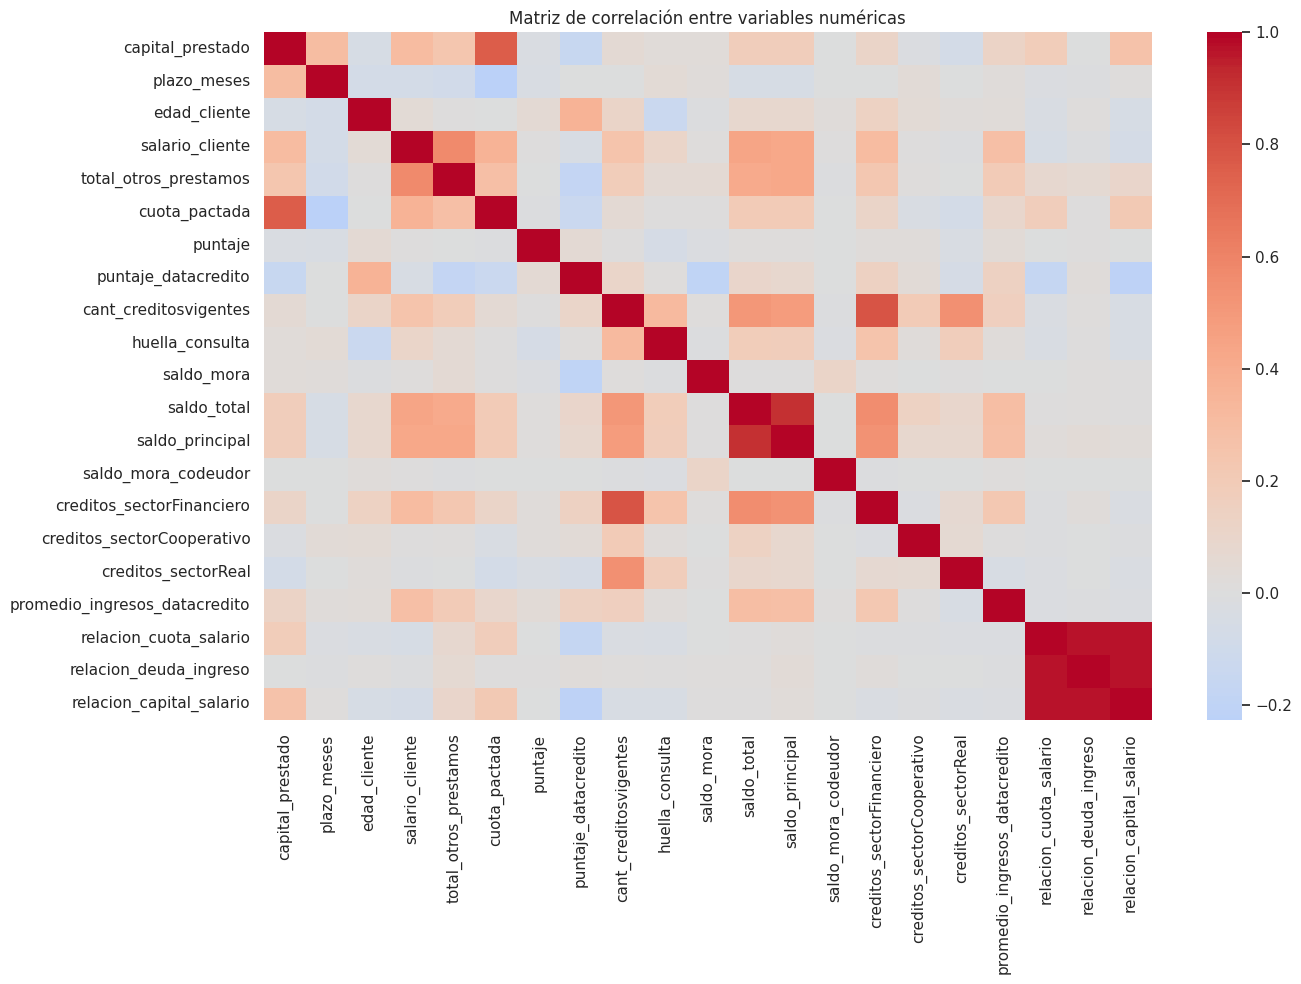

In [40]:
# Matriz de correlación
plt.figure(figsize=(14, 10))
corr = df[cols_numericas].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de correlación entre variables numéricas')
plt.tight_layout()
plt.show()

In [41]:
# Pares de variables más correlacionadas (en valor absoluto, excluyendo diagonal)
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1].drop_duplicates()
corr_pairs.head(15)

,,0
relacion_cuota_salario,relacion_deuda_ingreso,0.975607
relacion_deuda_ingreso,relacion_capital_salario,0.972810
relacion_cuota_salario,relacion_capital_salario,0.968983
saldo_total,saldo_principal,0.912819
creditos_sectorFinanciero,cant_creditosvigentes,0.791253
capital_prestado,cuota_pactada,0.764104
salario_cliente,total_otros_prestamos,0.575544
saldo_total,creditos_sectorFinanciero,0.556024
creditos_sectorReal,cant_creditosvigentes,0.540677
creditos_sectorFinanciero,saldo_principal,0.537307


**Pares con correlación alta detectados:**
- `capital_prestado` ↔ `cuota_pactada` (≈ 0.76): esperable, a mayor capital prestado, mayor la cuota mensual pactada, para un plazo similar.
- `cant_creditosvigentes` ↔ `creditos_sectorFinanciero` (≈ 0.79): probablemente la mayoría de los créditos vigentes de un cliente están concentrados en el sector financiero, así que ambas variables miden en gran parte lo mismo.
- `saldo_total` ↔ `saldo_principal` (≈ 0.73): coherente, ya que el saldo total normalmente se compone en buena parte del saldo principal (capital pendiente).

**Implicación para el modelado:** estos pares muestran **multicolinealidad**. Para modelos lineales (regresión logística) esto puede inflar la varianza de los coeficientes y dificultar su interpretación; conviene:
- Calcular el **VIF** (Variance Inflation Factor) de cada variable antes de modelar.
- Elegir una variable representativa por par (o combinarlas, p. ej. `saldo_total - saldo_principal` como "saldo no-principal") en vez de incluir ambas.
- Si se usan modelos de árboles, la multicolinealidad afecta menos la predicción pero sigue distorsionando la interpretación de importancia de variables.


**Multicolinealidad entre atributos derivados: VIF**

Como se anticipó en el análisis de correlación anterior, se calcula el VIF (Variance Inflation Factor) para confirmar si `relacion_cuota_salario`, `relacion_deuda_ingreso` y `relacion_capital_salario` son redundantes entre sí.

In [42]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

cols_vif = ['relacion_cuota_salario', 'relacion_deuda_ingreso', 'relacion_capital_salario',
            'capital_prestado', 'cuota_pactada', 'creditos_sectorFinanciero', 'cant_creditosvigentes']
X = df_modelo[cols_vif].dropna()
vif = pd.DataFrame({
    'variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif.sort_values('VIF', ascending=False))

                    variable         VIF
0     relacion_cuota_salario  109.015589
2   relacion_capital_salario  100.119323
1     relacion_deuda_ingreso   21.488979
3           capital_prestado    6.914606
6      cant_creditosvigentes    6.200334
4              cuota_pactada    5.977260
5  creditos_sectorFinanciero    5.356038


Las tres razones creadas (`relacion_cuota_salario`, `relacion_deuda_ingreso`, `relacion_capital_salario`) comparten el mismo denominador (`salario_cliente`) y numeradores ya correlacionados entre sí, lo que se confirmó con el Factor de Inflación de Varianza (VIF):

| Variable | VIF |
|---|---|
| `relacion_cuota_salario` | 109.0 |
| `relacion_capital_salario` | 100.1 |
| `relacion_deuda_ingreso` | 21.5 |

**Justificación:** un VIF > 10 ya se considera problemático (indica que la variable es casi una combinación lineal de las demás); aquí dos de las tres razones superan 100. Mantener las tres no aporta información adicional real, solo redundancia, y en modelos lineales/basados en distancia infla artificialmente la varianza de los coeficientes.

Se conserva únicamente `relacion_cuota_salario`, por ser el indicador estándar de capacidad de pago (cuota/ingreso) en riesgo crediticio, y se eliminan `relacion_deuda_ingreso` y `relacion_capital_salario`.

In [43]:
# Eliminación de razones derivadas redundantes por alta multicolinealidad (VIF > 100)
# Se conserva 'relacion_cuota_salario' como indicador estándar de la capacidad de pago

df_modelo = df_modelo.drop(columns=['relacion_deuda_ingreso', 'relacion_capital_salario'])

print("'relacion_deuda_ingreso' y 'relacion_capital_salario' eliminadas del set predictivo.")
print(f"Columnas restantes: {df_modelo.shape[1]}")

'relacion_deuda_ingreso' y 'relacion_capital_salario' eliminadas del set predictivo.
Columnas restantes: 23


In [44]:
# Verificación: revisar si la multicolinealidad se resolvió

cols_vif_final = ['relacion_cuota_salario', 'capital_prestado', 'cuota_pactada',
                   'cant_creditosvigentes', 'creditos_sectorFinanciero']
X = df_modelo[cols_vif_final].dropna()
vif_final = pd.DataFrame({
    'variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif_final.sort_values('VIF', ascending=False))

                    variable       VIF
3      cant_creditosvigentes  6.061298
1           capital_prestado  5.861038
2              cuota_pactada  5.553021
4  creditos_sectorFinanciero  5.340223
0     relacion_cuota_salario  1.047006


**Consolidación de variables de saldo (retroalimentación docente)**

El profesor señaló en la retroalimentación que, de las variables de saldo (`saldo_mora`, `saldo_total`, `saldo_principal`, `saldo_mora_codeudor`), conviene quedarse con una sola para el set de modelado, evitando redundancia.

Al revisar la correlación entre las cuatro variables:

| | `saldo_mora` | `saldo_total` | `saldo_principal` | `saldo_mora_codeudor` |
|---|---|---|---|---|
| `saldo_mora` | 1.000 | 0.004 | 0.005 | 0.111 |
| `saldo_total` | 0.004 | 1.000 | **0.913** | -0.005 |
| `saldo_principal` | 0.005 | **0.913** | 1.000 | -0.007 |
| `saldo_mora_codeudor` | 0.111 | -0.005 | -0.007 | 1.000 |

Se observa que **solo `saldo_total` y `saldo_principal` son redundantes entre sí** (correlación de 0.913, mucho más alta que la reportada inicialmente en la sección 3.3 antes de aplicar la winsorización a `saldo_total`). Tiene sentido de negocio: el saldo total de un crédito está compuesto en su gran mayoría por el saldo principal (capital pendiente), con una pequeña porción adicional de intereses u otros cargos.

`saldo_mora` y `saldo_mora_codeudor`, en cambio, **no están correlacionadas** con `saldo_total`/`saldo_principal` (correlaciones cercanas a 0) ni entre sí de forma fuerte (0.111): miden algo distinto (montos específicamente en mora, del titular y del codeudor respectivamente), por lo que no forman parte de esta consolidación — `saldo_mora_codeudor` corresponde, de hecho, a otro punto separado de la retroalimentación del profesor, pendiente de abordar aparte.

**Decisión:** se conserva `saldo_total` (por ser la medida más completa e integral del saldo del crédito) y se elimina `saldo_principal` del set de modelado, ya que su información queda prácticamente capturada por `saldo_total`.

In [ ]:
# Verificación de la correlación entre las variables de saldo
cols_saldo = ['saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor']
print(df[cols_saldo].corr().round(3))

# Eliminación de 'saldo_principal' del set predictivo por alta redundancia con 'saldo_total'
# Justificación: correlación de 0.913 entre ambas variables (ver tabla anterior);
# se conserva 'saldo_total' por ser la medida más completa del saldo del crédito.
df_modelo = df_modelo.drop(columns=['saldo_principal'])

print("\n'saldo_principal' eliminado del set predictivo (redundante con 'saldo_total').")
print(f"Columnas restantes: {df_modelo.shape[1]}")


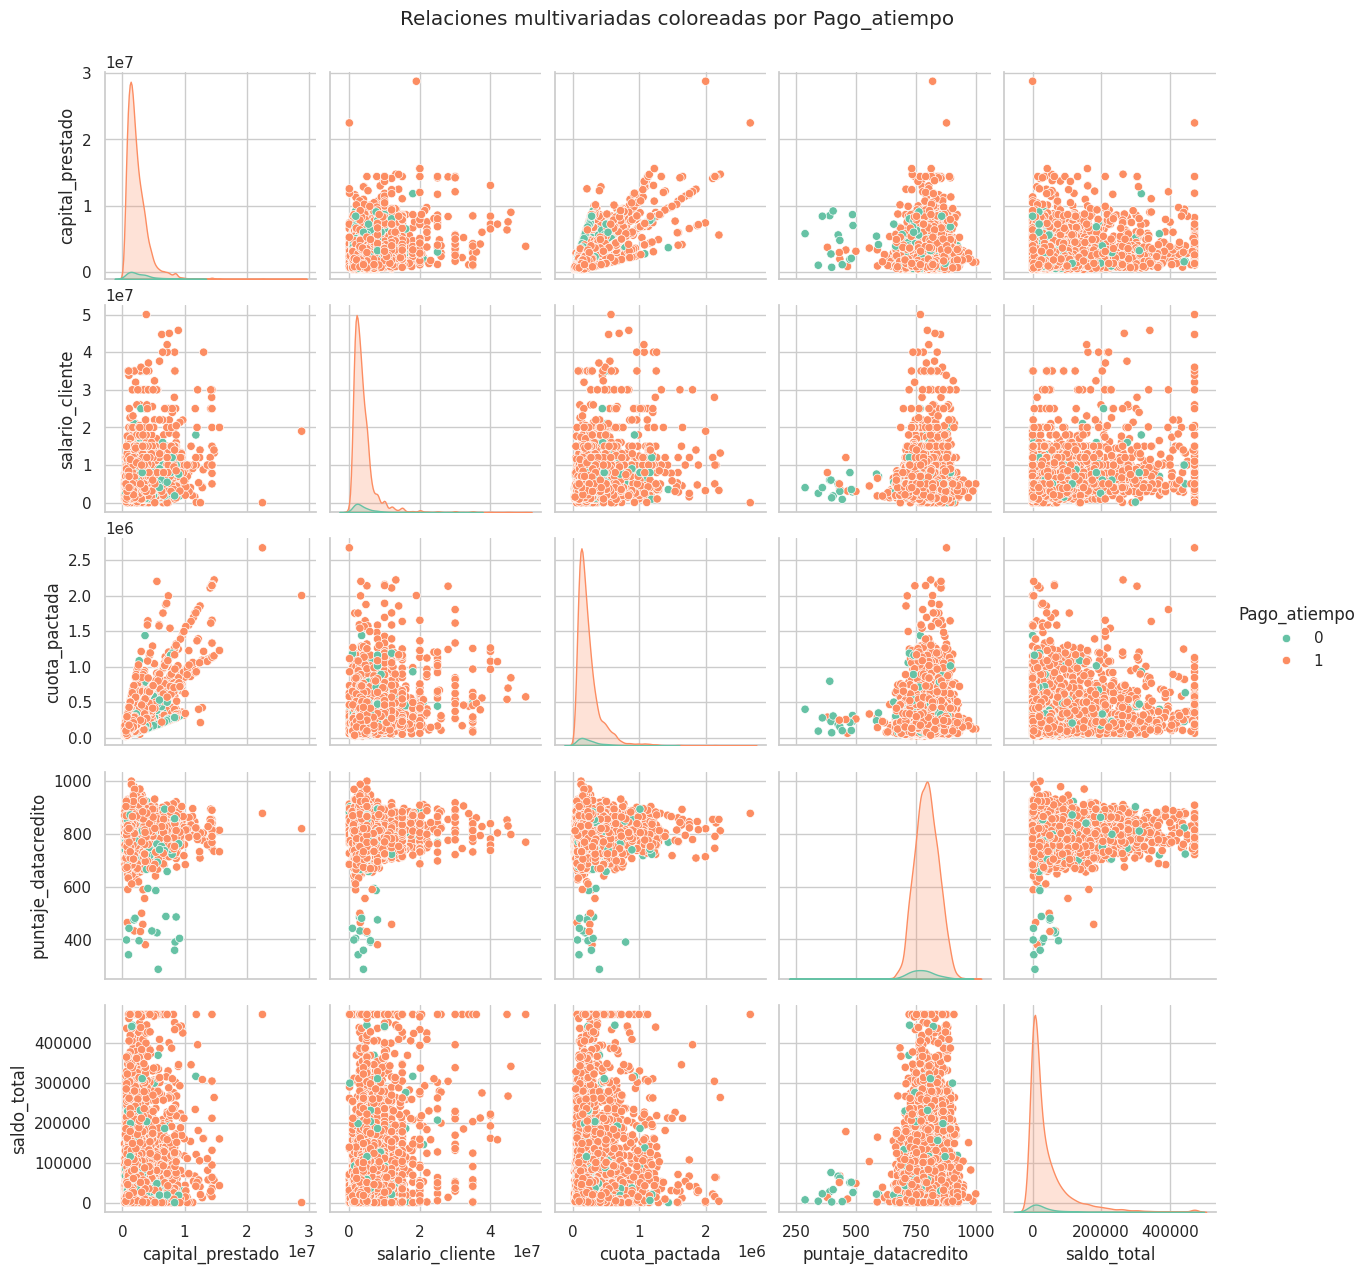

In [45]:
# Pairplot con un subconjunto de variables relevantes, coloreado por la variable objetivo
subset_vars = ['capital_prestado', 'salario_cliente', 'cuota_pactada', 'puntaje_datacredito', 'saldo_total']
subset_vars = [v for v in subset_vars if v in df.columns]

sns.pairplot(df[subset_vars + [target]].dropna(), hue=target, diag_kind='kde', palette='Set2')
plt.suptitle('Relaciones multivariadas coloreadas por Pago_atiempo', y=1.02)
plt.show()

Se puede observar de mejor manera la alta correlación de las variables mencioandas anteriormente

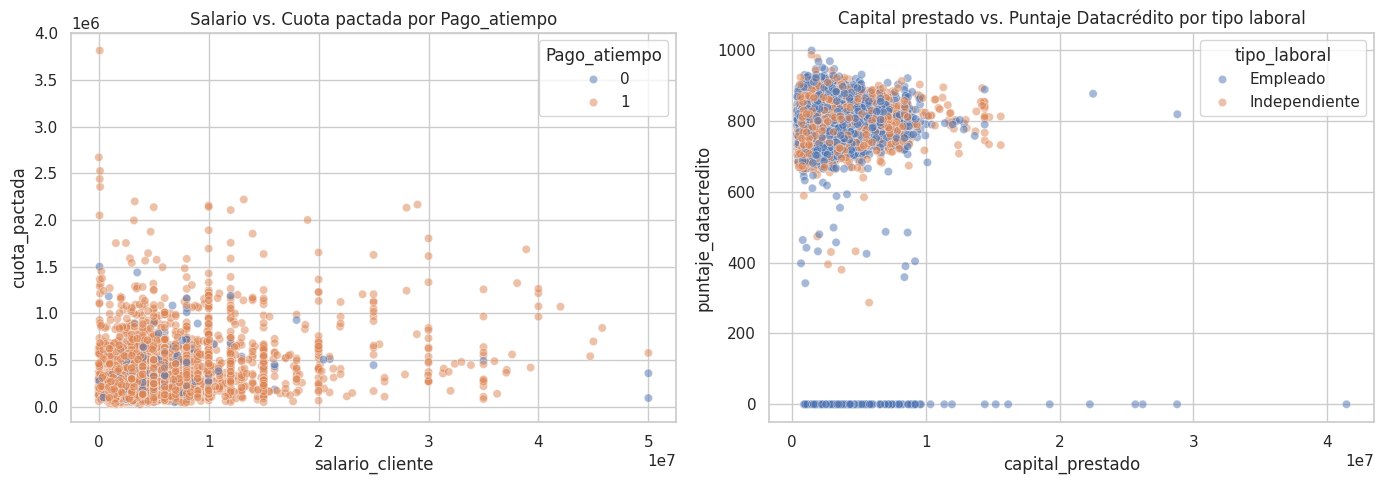

In [46]:
# Dispersión entre dos variables clave, con hue por variable objetivo y por tipo_laboral
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='salario_cliente', y='cuota_pactada', hue=target, alpha=0.5, ax=axes[0])
axes[0].set_title('Salario vs. Cuota pactada por Pago_atiempo')

sns.scatterplot(data=df, x='capital_prestado', y='puntaje_datacredito', hue='tipo_laboral', alpha=0.5, ax=axes[1])
axes[1].set_title('Capital prestado vs. Puntaje Datacrédito por tipo laboral')
plt.tight_layout()
plt.show()

In [47]:
# Tabla cruzada multivariable: tipo_laboral x tendencia_ingresos, con tasa de mora promedio
if 'tendencia_ingresos' in df.columns:
    tabla_multi = df.pivot_table(index='tipo_laboral', columns='tendencia_ingresos',
                                  values=target, aggfunc=lambda s: (s.astype(int)==0).mean()*100)
    print("Tasa de mora (%) por tipo_laboral y tendencia_ingresos:")
    tabla_multi.round(2)

Tasa de mora (%) por tipo_laboral y tendencia_ingresos:


/tmp/ipykernel_1893/2551691415.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabla_multi = df.pivot_table(index='tipo_laboral', columns='tendencia_ingresos',


Con estas verificaciones (fuga de información y multicolinealidad) resueltas dentro del propio EDA, `df_modelo` queda como el conjunto de datos curado para los siguientes pasos del proyecto.

Estas mismas reglas de negocio, la corrección de escala, la creación de `relacion_cuota_salario` y la exclusión de `puntaje` ya están formalizadas como un pipeline reutilizable de `scikit-learn` en `feature_engineering.py`, para poder aplicarse de forma consistente sobre datos nuevos sin repetir todo el análisis exploratorio.

Estas mismas reglas de negocio, la corrección de escala, la creación de `relacion_cuota_salario` y la exclusión de `puntaje` ya están formalizadas como un pipeline reutilizable de `scikit-learn` en `feature_engineering.py`, para poder aplicarse de forma consistente sobre datos nuevos sin repetir todo el análisis exploratorio.